# Preprocessing and Data Organization  

In the last labs, you learned how we use the **General Linear Model (GLM)** to analyse fMRI data.  
At the heart of the GLM is a simple idea:  

$$\textcolor{blue}{y} = \textcolor{orange}{X}\textcolor{darkred}{\beta} + \textcolor{gray}{\varepsilon}$$  

- <span style="color:#1f77b4;">$\textcolor{blue}{y}$</span> = the observed BOLD signal  
- <span style="color:#ff7f0e;">$\textcolor{orange}{X}\textcolor{darkred}{\beta}$</span> = the signal we want to explain (our design)  
- <span style="color:#2ca02c;">$\textcolor{gray}{\varepsilon}$</span> = everything else — the **error term**  

For the GLM to give us meaningful results, the error term <span style="color:#2ca02c;">$\epsilon$</span> needs to be as small and "well-behaved" as possible.  
This is where **preprocessing** comes in.  

The BOLD signal is *very noisy*. Task-related activation typically accounts for only **2–5%** of the total variance — the rest is noise coming from the scanner, the participant, or the environment.   Preprocessing steps do not change our design <span style="color:#ff7f0e;">$X$</span> or the parameter estimates $\beta$ directly. Instead, they reduce unwanted sources of variance, making the data **cleaner** and the error term <span style="color:#2ca02c;">$\epsilon$</span> **smaller**.  

Examples:  
- **Motion correction** reduces variance caused by head movement.  
- **Distortion correction** reduces variance from scanner field inhomogeneities.  
- **Slice timing correction** ensures that voxel time series are properly aligned in time.  
- **Coregistration and normalisation** allow us to compare the *same brain regions* across participants.  
- **Spatial smoothing** reduces voxel-level noise, directly lowering the variance of <span style="color:#2ca02c;">$\epsilon$</span>.  

In this notebook, you’ll learn about **signal processing methods** that help us minimise noise and maximise signal. You’ll start by implementing some of these steps directly in Python to understand the principles behind them.  

In practice, however, preprocessing today is highly standardised and typically performed with tools such as [**fMRIPrep**](https://fmriprep.org/).  
These pipelines assume that data are organised according to the **Brain Imaging Data Structure (BIDS)**, a widely used standard for fMRI data organisation.  
So in addition to preprocessing, you’ll also learn how to structure your data in BIDS format and then use *fMRIPrep* to preprocess it.  

---
## What you’ll learn  
- How **realignment** helps reduce motion artefacts  
- How **spatial normalisation** aligns data to a common space  
- How **spatial smoothing** can reduce noise  
- How to organise data in the **Brain Imaging Data Structure (BIDS)**  

---
**Expected time to complete**: 4–5 hours  

**Attribution**:  
- Updated by *Joe Bathelt (2025)*
- Developed by *Joe Bathelt (2024)*  
- Including original materials from *Lukas Snoek (2019)*  

In [39]:
from mpl_toolkits import mplot3d

import matplotlib.pyplot as plt
from nibabel.affines import apply_affine, from_matvec, to_matvec
from scipy.ndimage import affine_transform, map_coordinates
import nibabel as nib
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact, FloatSlider
from IPython.display import display
import os
from subprocess import call
from shutil import copyfile


from scipy.interpolate import interp1d
from nilearn.image.image import mean_img
from nilearn.plotting import plot_epi
import pandas as pd
from scipy.interpolate import InterpolatedUnivariateSpline as Interp

In [40]:
import os
import urllib.request

def download_file(url, outfile):
    """Download file from URL if not already present."""
    if not os.path.exists(outfile):
        print(f"Downloading {outfile}...")
        urllib.request.urlretrieve(url, outfile)
        print(f"Saved as {outfile}")
    else:
        print(f"{outfile} already exists, skipping download.")

# Downloading some required data
for url, name in zip([
        "https://www.dropbox.com/scl/fi/s88scelnqsngdjkqo5wzc/motion_effect.gif?rlkey=8g0xuc3ba2hyerdvr3if79x2j&dl=1",
        "https://www.dropbox.com/scl/fi/l20txfo2wm3hdedmc6gls/func_ref.nii.gz?rlkey=npwweciiwdeak0knc9hx4eaf3&dl=1",
        "https://www.dropbox.com/scl/fi/zji5axwbtrkgoxvvviwgh/fd_before.txt?rlkey=17qchey8a1hh1go5tnacdto3q&dl=1",
        "https://www.dropbox.com/scl/fi/km4wke2r5atznd0rmgdav/fd_after.txt?rlkey=m805jxby8s5ef76w538srw9x2&dl=1",
        "https://www.dropbox.com/scl/fi/lwvqxktn4owjvwih6io17/figure_fMRIPrep_movement.png?rlkey=kzy8adr6rf9a61bph3dav8kcp&dl=1",
        "https://www.dropbox.com/scl/fi/t37kcc5vfbt41vuye69zj/figure_fMRIPrep_movement_a.png?rlkey=rf5yaff5xn1z04k36hw6djqj5&dl=1",
        "https://www.dropbox.com/scl/fi/0n8gbsdnjmqdhg1qfhlih/figure_fMRIPrep_movement_b.png?rlkey=aarhfxmgem3ube2i2tnanaxwe&dl=1",
        "https://www.dropbox.com/scl/fi/4alju61i0cq6dbj7s3eln/figure_susceptibility_illustration.png?rlkey=x6u9e6jeslurrwxeql5fvxbn5&dl=1",
        "https://www.dropbox.com/scl/fi/ibg4r3iz19vaavt9cqog4/figure_fMRIPrep_fieldmap.png?rlkey=28b26bt0pglaatk88s954b72u&dl=1",
        "https://www.dropbox.com/scl/fi/8x1koxtvvdskn9ifea706/figure_T1vsEPI.png?rlkey=pyxqpdmuy8bqbroeiy1eqj97p&dl=1",
        "https://www.dropbox.com/scl/fi/yc6jwneiougdgm95a7q0x/figure_anatomy_comparison.png?rlkey=amlqs8hhvram8rjoee1gk0qn7&dl=1",
        "https://www.dropbox.com/scl/fi/4jp6gk1ff870v752hiocf/sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz?rlkey=8u21e61jnmghgx3qfsskqja86&dl=1",
        "https://www.dropbox.com/scl/fi/ybcoqc8skoaufguqocl1w/sub-03_ses-1_acq-AxialNsig2Mm1_desc-preproc_T1w.nii.gz?rlkey=2fq2639beaurl9ubz3y5a5g6g&dl=1"
    ],
    [
        "motion_effect.gif",
        "func_ref.nii.gz",
        "fd_before.txt",
        "fd_after.txt",
        "figure_fMRIPrep_movement.png",
        "figure_fMRIPrep_movement_a.png",
        "figure_fMRIPrep_movement_b.png",
        "figure_susceptibility_illustration.png",
        "figure_fMRIPrep_fieldmap.png",
        "figure_T1vsEPI.png",
        "figure_anatomy_comparison.png",
        "sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz",
        "sub-03_ses-1_acq-AxialNsig2Mm1_desc-preproc_T1w.nii.gz"
    ]):

    download_file(url, name)

Saved as motion_effect.gif


Saved as func_ref.nii.gz


Saved as fd_before.txt


Saved as fd_after.txt


Saved as figure_fMRIPrep_movement.png


...

Saved as figure_fMRIPrep_fieldmap.png


Saved as figure_T1vsEPI.png


Saved as figure_anatomy_comparison.png


Saved as sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz


Saved as sub-03_ses-1_acq-AxialNsig2Mm1_desc-preproc_T1w.nii.gz


## Part 1: Brain Imaging Data Structure (BIDS)  

In the early days of neuroimaging, each lab — and often each individual researcher — had their own (sometimes improvised) system for organising data.  
This made it **time-consuming** to reuse data, and nearly impossible to develop software that worked seamlessly across datasets.  

With the rise of open science and data sharing, the **Brain Imaging Data Structure (BIDS)** was introduced to solve these problems.  
BIDS defines a clear, standardised system for how neuroimaging data should be organised and documented.  
Over time, it has grown to cover almost every type of data in cognitive neuroscience.  

In this section, you’ll learn the fundamentals of BIDS and how it applies specifically to fMRI data.  

---
### Key Features of BIDS  

- **Folder structure**  
  - A BIDS dataset lives in a single directory.  
  - The top level contains files like `dataset_description.json` (with information about the dataset).  
  - Each participant has a folder named `sub-<participant_id>` with subfolders for modalities, e.g. `anat/` (anatomical) and `func/` (functional).  

- **File naming**  
  - Consistent naming makes it easy to understand what each file contains.  
  - Example: `sub-01_task-rest_bold.nii.gz`  
    - `sub-01`: participant ID  
    - `task-rest`: task type  
    - `bold`: BOLD fMRI data  

- **Metadata**  
  - Stored in `.json` sidecar files (e.g., `sub-01_task-rest_bold.json`).  
  - Includes acquisition parameters, scanner details, and task conditions.  
  - Ensures analyses are reproducible and data can be shared without needing to consult the original authors.  

- **BIDS Validator**  
  - Online tool that checks whether a dataset follows the BIDS standard.  
  - Reports errors and warnings, helping researchers fix issues before sharing data.  

---
👉 Next, we’ll explore a real BIDS dataset and learn how to:  
- navigate the folder structure,  
- read metadata

Click on this link to open the NI-edu dataset on OpenNeuro: [OpenNeuro: ds003965 (version 1.0.0)](https://openneuro.org/datasets/ds003965/versions/1.0.0)

The dataset includes **anatomical images**, **functional images**, and **metadata files** for one participant (`sub-03`).  
But what do these different files mean?  

- **README files** → contain general information about the dataset, such as task descriptions and scanner details.  
- **JSON files** → store detailed metadata (e.g., acquisition parameters, timing information, and task conditions) in a standardised format.  
- **NIfTI files (`.nii` or `.nii.gz`)** → hold the actual imaging data, including anatomical scans and functional runs.  

Together, these files ensure that the dataset is both **human-readable** and **machine-readable**, making it easy to share, validate, and analyse.  

<div class='alert alert-warning'>
<b>ToDo</b> (3 point): 
For this exercise, we won’t download the data to the server.  
Instead, you’ll **inspect the dataset directly on OpenNeuro**:

Link:  [OpenNeuro: ds003965 (version 1.0.0)](https://openneuro.org/datasets/ds003965/versions/1.0.0)

When you open the link, you’ll see the dataset organised in **BIDS format**.  
Take a few minutes to explore the structure:

- At the **top level**, look for files such as:
  - `dataset_description.json` → describes the dataset  
  - `README` → general information  
  - `participants.tsv` → participant table  

- Inside the **participant folder** (e.g. `sub-03/`), check for:
  - `anat/` → anatomical images (e.g. `sub-03_T1w.nii.gz`)  
  - `func/` → functional runs (e.g. `sub-03_task-flocBLOCKED_bold.nii.gz`)  

- Notice the **naming conventions**:
  - `sub-03` = participant ID  
  - `task-flocBLOCKED` = task name  
  - `bold` = BOLD fMRI data type  

👉 **Your task**:  
Browse through the dataset on OpenNeuro and answer the following questions:

1. **Functional data**  
   - What is the *relative path* of the **`flocBLOCKED`** task file in the first session for participant `sub-03`?  Store this as `func_filename`

2. **Anatomical data**  
   - What is the *relative path* of the **T1-weighted anatomical image** for participant `sub-03`?  Store this as `anat_filename`

3. **Events metadata**  
   - Open an `events.tsv` file for the **`flocBLOCKED`** task.  
   - Which **columns** does it contain?  Store the the labels of the first four columns as an array called `event_columns`
    
💡 Hint: A relative path looks like this `sub-03/ses-1/anat/sub-03_ses-1_acq-AxialNsig2Mm1_T1w.json`
</div>

In [41]:
# --- 1. Relative path of flocBLOCKED for sub-03 ---
# YOUR CODE HERE
func_filename_solution = 'sub-03/ses-1/func/sub-03_ses-1_task-flocBLOCKED_bold.nii.gz'
assert func_filename == func_filename_solution
# raise NotImplementedError()

AssertionError: 

In [42]:
# Feedback cell
if 'func_filename' not in locals():
    print('The variable "func_filename" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(func_filename, str):
    print('The variable "func_filename" should be a string.')
elif '/' not in func_filename:
    print('Did you include the relative path? It should contain forward slashes like this "/"')
print('Your answer passed the automated checks.')

Your answer passed the automated checks.


In [43]:
### BEGN HIDDEN TESTS
func_filename_solution = 'sub-03/ses-1/func/sub-03_ses-1_task-flocBLOCKED_bold.nii.gz'
assert func_filename == func_filename_solution
### END HIDDEN TESTS

AssertionError: 

In [8]:
# --- 2. Relative path of T1w for sub-03 ---
### BEGIN SOLUTION
anat_filename = 'sub-03/ses-1/anat/sub-03_ses-1_acq-AxialNsig2Mm1_T1w.nii.gz'
### END SOLUTION

In [9]:
# Feedback cell
if 'anat_filename' not in locals():
    print('The variable "anat_filename" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(anat_filename, str):
    print('The variable "func_filename" should be a string.')
elif '/' not in anat_filename:
    print('Did you include the relative path? It should contain forward slashes like this "/"')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


In [10]:
# --- 3. Columns of the events file ---
### BEGIN SOLUTION
event_columns = np.array(['onset', 'duration', 'trial_type', 'stim_name'])
### END SOLUTION

In [11]:
# Feedback cell
if 'event_columns' not in locals():
    print('The variable "event_columns" is not defined. Check that you created and named the variable correctly.')
elif not event_columns.shape == (4,):
    print('The variable "event_columns" should be an array with shape (4,).')
elif not event_columns[0] == 'onset':
    print('Please check your answer. The first column should be labelled "onset"')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


### BIDS Apps  

Once data are organised in BIDS format, you can run them through **BIDS Apps** — specialised, containerised software packages designed for neuroimaging.  
Because they are containerised (using Docker or similar technologies), BIDS Apps:  

- work on any system (local computer, HPC cluster, or cloud),  
- require minimal setup, and  
- are easy to share and reproduce.  

There are BIDS Apps for many stages of analysis — from preprocessing to statistical modelling and visualisation.  

The most widely used example is **fMRIPrep**, a robust pipeline for fMRI preprocessing. 

We won’t run fMRIPrep here, because:  

- it takes a long time to process even small datasets, and  
- running it yourself doesn’t teach you much (the command is very simple).  

Instead, in the next section we’ll break down the **preprocessing steps that fMRIPrep performs**.  
This way, you’ll understand what happens “under the hood” when you later use automated pipelines in your own research.  

## Part 2: Signal Processing  

Preprocessing fMRI data involves a series of **signal cleaning and alignment steps**.  
Together, these steps prepare the data for statistical analysis and are often referred to as *preprocessing*.  

The most common steps include:  
1. **Skull stripping** – removing non-brain tissue  
2. **Realignment / motion correction** – correcting for head movement  
3. **Susceptibility distortion correction** – compensating for magnetic field inhomogeneities  
4. **Slice timing correction** – adjusting for differences in slice acquisition time  
5. **Coregistration** – aligning functional and anatomical images  
6. **Normalisation** – mapping data into a standard anatomical space  

---

### Anatomical images in preprocessing
High-resolution anatomical scans (T1- or T2-weighted) are usually acquired in the same session as the functional data.  
They are crucial for several preprocessing steps:  
- to create a **brain mask** (used in skull stripping),  
- to guide the **alignment** of functional data into a common anatomical space.  

These anatomical images also require their own preprocessing.  
Since this course focuses on **BOLD fMRI**, we won’t go into detail on anatomical processing.  

---

### Overview of preprocessing in fMRIPrep
The figure below illustrates the major preprocessing steps.  
In this notebook, we’ll focus on the **fMRI preprocessing steps** (highlighted on the right of the diagram).  

![Overview](https://media.springernature.com/m685/springer-static/image/art%3A10.1038%2Fs41592-018-0235-4/MediaObjects/41592_2018_235_Fig1_HTML.png)  

*Image source: [Esteban et al., 2019](https://doi.org/10.1038/s41592-018-0235-4)*  

---

### 1. Skull stripping
Functional images are often acquired together with the skull and other non-brain tissue.  
Since these regions carry no useful signal, they can be removed using a **brain mask**.  

Skull stripping is important because it affects the quality of later steps such as registration and normalisation.  
- Typically, the mask is created from the **anatomical scan** (higher resolution, better contrast).  
- The mask is then applied to the functional images.  

In this notebook we’ll assume skull stripping has already been done, and continue with the next steps.  

---

### 2. Motion correction (realignment)
Participants often move their heads slightly during scanning — even “well-behaved” subjects.  
This motion introduces artefacts that can strongly affect the BOLD signal.  

The animation below shows a participant’s head moving subtly between frames. This is the reason why motion correction is necessary.

![Motion Illustration](motion_effect.gif)

Because participant motion negatively affects data quality, **motion correction (or realignment)** is a crucial part of any preprocessing pipeline.  
The goal is to ensure that all volumes (i.e., the 3D images collected at each time point) are spatially aligned.  

Motion correction works by selecting a **reference volume** (usually the first or the middle one) and then “moving” all other volumes so they match the reference.  
This is achieved through two types of transformations:  

- **Translation** → shifts along the X, Y, and Z axes (left/right, up/down, front/back)  
- **Rotation** → rotations around the three axes (pitch, roll, yaw)  

![pitchrollyaw](https://www.researchgate.net/profile/Tsang_Ing_Ren/publication/279291928/figure/fig1/AS:292533185462272@1446756754388/Orientation-of-the-head-in-terms-of-pitch-roll-and-yaw-movements-describing-the-three.png)  

*Image from [Arcoverde Neto et al., 2014](https://www.researchgate.net/figure/Orientation-of-the-head-in-terms-of-pitch-roll-and-yaw-movements-describing-the-three_fig1_279291928)*  

This transformation has **six parameters** (three translations + three rotations) and is called a **rigid body registration**.  
Once these parameters are estimated, the moving volume is **resampled** into the space of the reference volume.  

Rigid body registration is a special case of the more general concept of **affine registration**, which can also include scaling and shearing.  
For motion correction, however, only translation and rotation are applied.  

<div class='alert alert-info'>
    <b>ToThink (1 points):</b>  Motion correction uses only <i>translations</i> and <i>rotations</i> (rigid body registration).
    Why do you think <i>scaling</i> and <i>shearing</i> are <b>not</b> applied in this step?
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

The shape and size of the head of a participant do not change during the scan, so we do not need to perform a scaling transformation. Applying shearing would deform the brain, and this would be biologically inaccurate. 


#### 2.1 Affine Registrations  

An **affine registration** describes how one image should be transformed to align with another using a **$4 \times 4$ affine matrix**.  

- In **Week 1**, we saw that affine matrices map voxel indices $(i, j, k)$ to *world coordinates* $(x, y, z)$.  
- Here, the same mathematical tool is used differently: the affine matrix now encodes how voxel coordinates in the **original (uncorrected)** image should be transformed into coordinates in the **corrected** image.  

Formally:  

$$
\begin{bmatrix} 
i_{\text{corr}} \\ j_{\text{corr}} \\ k_{\text{corr}} \\ 1 
\end{bmatrix}
= 
A \cdot 
\begin{bmatrix} 
i \\ j \\ k \\ 1 
\end{bmatrix}
$$

where $A$ is the affine transformation matrix.  

---

**Example**:  
Suppose `A_example` encodes a translation of 3 voxels downward (superior → inferior).  
By multiplying any coordinate vector $\begin{bmatrix} i, j, k, 1 \end{bmatrix}^T$ with `A_example`, we obtain its new location in the **motion-corrected image**.  

In [12]:
A_example = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 3],
    [0, 0, 0, 1]
])

# Note that we always have to append a 1, just like in week 1
coord = np.array([0, 0, 0, 1])  # the middle of the image!
corr_coord = A_example @ coord
print(corr_coord[:3])

[0 0 3]


As expected, the affine transformation above shows that the origin coordinate \((0, 0, 0)\) maps to the corrected coordinate \((0, 0, 3)\) after translating the image 3 voxels downward.  

But how is this translation encoded in the affine matrix?  
For **translations**, it’s straightforward. A shift by \((x, y, z)\) is represented as:

$$
\begin{bmatrix} 
i_{\mathrm{trans}} \\ j_{\mathrm{trans}} \\ k_{\mathrm{trans}} \\ 1 
\end{bmatrix}
=
\begin{bmatrix}
1 & 0 & 0 & x \\
0 & 1 & 0 & y \\
0 & 0 & 1 & z \\
0 & 0 & 0 & 1
\end{bmatrix}
\cdot
\begin{bmatrix}
i \\ j \\ k \\ 1
\end{bmatrix}
$$

---

For **rotations**, things are a bit more involved.  
Rotations about the X, Y, and Z axes (by angles \(x, y, z\) in radians) are each represented by their own 4×4 matrix.  
For example:  

- Rotation around the **X-axis**:
$$
\begin{bmatrix}
1 & 0 & 0 & 0 \\
0 & \cos(x) & -\sin(x) & 0 \\
0 & \sin(x) & \cos(x) & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

- Rotation around the **Y-axis**:
$$
\begin{bmatrix}
\cos(y) & 0 & \sin(y) & 0 \\
0 & 1 & 0 & 0 \\
-\sin(y) & 0 & \cos(y) & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

- Rotation around the **Z-axis**:
$$
\begin{bmatrix}
\cos(z) & -\sin(z) & 0 & 0 \\
\sin(z) & \cos(z) & 0 & 0 \\
0 & 0 & 1 & 0 \\
0 & 0 & 0 & 1
\end{bmatrix}
$$

---

The full rotation is obtained by **multiplying these matrices together**.  
This combined matrix can then be applied to voxel coordinates just like the translation matrix.

---

By combining **translation** and **rotation**, we obtain an affine matrix that describes any **rigid body transformation** (the basis of motion correction).  

![affine_transformations](https://nipy.org/nibabel/_images/illustrating_affine.png)  

*Image from*: [NiBabel documentation](https://nipy.org/nibabel/_images/illustrating_affine.png)  

<div class='alert alert-warning'>

<b>ToDo</b> (1 point)

Construct a **translation matrix** that shifts voxel coordinates by  
$$(x, y, z) = (0, 0, 3)$$ in homogeneous coordinates.

👉 Requirements:
- Use **NumPy** to create a 4×4 matrix called `A`.
- The upper-left 3×3 block should be the **identity** (no rotation).
- The last column should represent the translation vector.
- Verify that applying `A` to the origin `(0, 0, 0)` yields `(0, 0, 3)`.

</div>

In [13]:
# Implement your ToDo here
# YOUR CODE HERE
import numpy as np

# translation amounts
tx, ty, tz = 0, 0, 3

# 4×4 affine transformation matrix
A = np.array([
    [1, 0, 0, tx],
    [0, 1, 0, ty],
    [0, 0, 1, tz],
    [0, 0, 0, 1]
], dtype=float)

print("A =\n", A)

# apply A to the origin in homogeneous coordinates
origin = np.array([0, 0, 0, 1], dtype=float)
translated = A @ origin

print("A at origin =", translated)

# raise NotImplementedError()

A =
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 3.]
 [0. 0. 0. 1.]]
A at origin = [0. 0. 3. 1.]


In [14]:
# Feedback cell
if "A" not in locals():
    print('The variable "A" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(A, np.ndarray):
    print('"A" should be a NumPy array.')
elif A.shape != (4, 4):
    print('Matrix "A" should have shape (4, 4).')
elif not np.allclose(A[:3, :3], np.eye(3)):
    print('The upper-left 3×3 block should be the identity matrix (no rotation).')
elif not np.allclose(A[:3, 3], [0, 0, 3]):
    print('The translation vector should be (0, 0, 3).')
else:
    origin = np.array([0, 0, 0, 1])
    transformed = A @ origin
    if not np.allclose(transformed, [0, 0, 3, 1]):
        print('The matrix does not correctly translate the origin to (0, 0, 3).')
    else:
        print('Your translation matrix passed the automated checks.')

Your translation matrix passed the automated checks.


### How do we know which transformations to apply?  

Of course, we cannot manually inspect every single fMRI volume and “guess” the right combination of translations and rotations to align them.  
Instead, motion correction relies on an **optimization algorithm**:  

- The algorithm starts with an initial guess of the affine transformation.  
- It then **iteratively adjusts the six parameters** (three translations + three rotations).  
- After each adjustment, it computes how well the moving image matches the reference image using a **cost function** (e.g. the sum of squared differences).  
- The process continues until the cost function is minimized, meaning the two images are as well aligned as possible.  

---

👉 Try it out below: move the sliders to transform the moving image until it aligns with the reference.  
Notice how the **cost function value decreases** as alignment improves.  

In [15]:
%matplotlib inline

import os
from copy import deepcopy

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import map_coordinates
import nibabel as nib
from ipywidgets import interact, FloatSlider

def build_translation_affine_2d(trans_x: float, trans_y: float) -> np.ndarray:
    """
    Build a 3x3 2D homogeneous translation matrix that maps
    reference pixel indices (i, j) -> source indices (i + trans_y, j + trans_x).

    Notes
    -----
    - We follow image-indexing convention: i = row (y), j = column (x).
    - The returned matrix A is applied to homogeneous coords [i, j, 1]^T.
    """
    A = np.array([[1.0, 0.0, float(trans_y)],
                  [0.0, 1.0, float(trans_x)],
                  [0.0, 0.0, 1.0]], dtype=float)
    return A


def apply_affine_coords_2d(A: np.ndarray, coords_last: np.ndarray) -> np.ndarray:
    """
    Apply a 3x3 affine to a field of 2D coordinates.

    Parameters
    ----------
    A : (3, 3) ndarray
        2D homogeneous affine matrix.
    coords_last : (H, W, 2) ndarray
        Coordinate grid in (i, j) order.

    Returns
    -------
    transformed : (H, W, 2) ndarray
        Transformed coordinates in (i, j) order.
    """
    H, W, _ = coords_last.shape
    ones = np.ones((H, W, 1), dtype=float)
    homo = np.concatenate([coords_last.astype(float), ones], axis=-1)            # (H, W, 3)
    flat = homo.reshape(-1, 3).T                                                # (3, H*W)
    out = (A @ flat).T[:, :2]                                                   # (H*W, 2)
    return out.reshape(H, W, 2)                                                 # (H, W, 2)


def warp_image_2d(image: np.ndarray, A: np.ndarray, order: int = 1,
                  cval: float = 0.0) -> np.ndarray:
    """
    Resample `image` at coordinates given by applying affine A to the
    target grid (backward mapping), using map_coordinates.

    Parameters
    ----------
    image : (H, W) ndarray
        Source (moving) image to be sampled.
    A : (3, 3) ndarray
        Affine mapping target grid -> source coords.
    order : int
        Spline interpolation order for map_coordinates (0=nearest, 1=linear, ...).
    cval : float
        Constant value used for points outside boundaries.

    Returns
    -------
    warped : (H, W) ndarray
        Resampled image.
    """
    H, W = image.shape
    i_coords, j_coords = np.meshgrid(np.arange(H), np.arange(W), indexing="ij")
    grid_ij = np.stack([i_coords, j_coords], axis=-1)                           # (H, W, 2)
    src_ij = apply_affine_coords_2d(A, grid_ij)                                 # (H, W, 2)
    # map_coordinates expects coords in separate arrays with shape (ndim, H, W)
    coords_for_map = np.stack([src_ij[..., 0], src_ij[..., 1]], axis=0)
    return map_coordinates(image, coords_for_map, order=order, mode="constant", cval=cval)

def apply_initial_translation(mri_slice: np.ndarray, trans_x: float, trans_y: float) -> np.ndarray:
    """Apply an initial (known) translation to create a 'moving' image."""
    A = build_translation_affine_2d(trans_x=trans_x, trans_y=trans_y)
    return warp_image_2d(mri_slice, A, order=1, cval=0.0)


def plot_affine_cost(mri_slice1: np.ndarray, mri_slice2: np.ndarray, trans_x: float = 0, trans_y: float = 0):
    """
    Interactive demo to illustrate a cost function (SSE) for 2D registration.
    - mri_slice1: moving image (will be transformed)
    - mri_slice2: reference image
    - trans_x/trans_y: user-controlled translation (columns/rows)
    """
    if mri_slice1.shape != mri_slice2.shape:
        raise ValueError("The two MRI slices must have the same dimensions.")

    # Build translation that maps target grid -> moving coords
    A = build_translation_affine_2d(trans_x=trans_x, trans_y=trans_y)
    transformed_slice = warp_image_2d(mri_slice1, A, order=1, cval=0.0)

    f, a = plt.subplots(ncols=3, figsize=(15, 5))
    a[0].imshow(transformed_slice, cmap='gray')
    a[0].set_xlabel('x', fontsize=16)
    a[0].set_ylabel('y', fontsize=16)
    a[0].set_title('Moving Image (transformed)', fontsize=18)

    a[1].imshow(mri_slice2, cmap='gray')
    a[1].set_xlabel('x', fontsize=16)
    a[1].set_ylabel('y', fontsize=16)
    a[1].set_title('Reference Image', fontsize=18)

    sse = float(np.sum((transformed_slice - mri_slice2) ** 2))
    a[2].bar(0, sse)
    a[2].set_ylim([0, max(1.0, sse * 1.1)])
    a[2].set_ylabel('SSE', fontsize=18)
    a[2].set_xlabel('Cost Function', fontsize=18)
    a[2].set_xticks([])
    a[2].set_title(f'Parameters: (tx={int(trans_x)}, ty={int(trans_y)})', fontsize=16)
    plt.tight_layout()
    plt.show()


# Load an example NIfTI and extract a 2D slice
img = nib.load(os.path.abspath('func_ref.nii.gz'))
mri_slice = img.get_fdata()[40, ...]
mri_slice1 = np.flipud(mri_slice.T)   # moving image
mri_slice2 = np.flipud(mri_slice.T)   # reference image

# Create an initially misaligned moving image by applying a random translation
rng = np.random.default_rng()
initial_trans_x = int(rng.integers(-5, 6))
initial_trans_y = int(rng.integers(-5, 6))
mri_slice1_translated = apply_initial_translation(mri_slice1, initial_trans_x, initial_trans_y)

def interactive_plot(trans_x, trans_y):
    plot_affine_cost(mri_slice1_translated, mri_slice2, trans_x, trans_y)

interact(
    interactive_plot,
    trans_x=FloatSlider(value=0, min=-30, max=30, step=1, description="tx (cols)"),
    trans_y=FloatSlider(value=0, min=-30, max=30, step=1, description="ty (rows)")
)

interactive(children=(FloatSlider(value=0.0, description='tx (cols)', max=30.0, min=-30.0, step=1.0), FloatSli…

<function __main__.interactive_plot(trans_x, trans_y)>

This demo shows how 2D images can be aligned by minimising a **cost function**.  
In practice, we do the same in 3D: applying translations and rotations in all three dimensions, across all volumes in a 4D fMRI dataset.  

### How do we know if motion correction worked?  
The cost function itself is not very informative — its values depend on image intensities, which differ between participants and sessions.  

A more useful approach is to examine the **motion parameters** estimated during realignment:  
- three translations (X, Y, Z), and  
- three rotations (pitch, roll, yaw).  

If the participant moved a lot, these plots will show large spikes.  
But inspecting six separate time series for every scan quickly becomes cumbersome.  

---

### Framewise Displacement (FD)  
To simplify, we often use a single summary metric: **framewise displacement (FD)**.  

- FD is calculated as the **sum of the absolute differences** (derivatives) of the six motion parameters between consecutive volumes.  
- Rotations are scaled into millimetres so they are comparable with translations.  
- High FD values indicate substantial head movement.  

👉 In the next step, we’ll compare **FD before and after motion correction** to see how well the procedure reduced motion effects.  

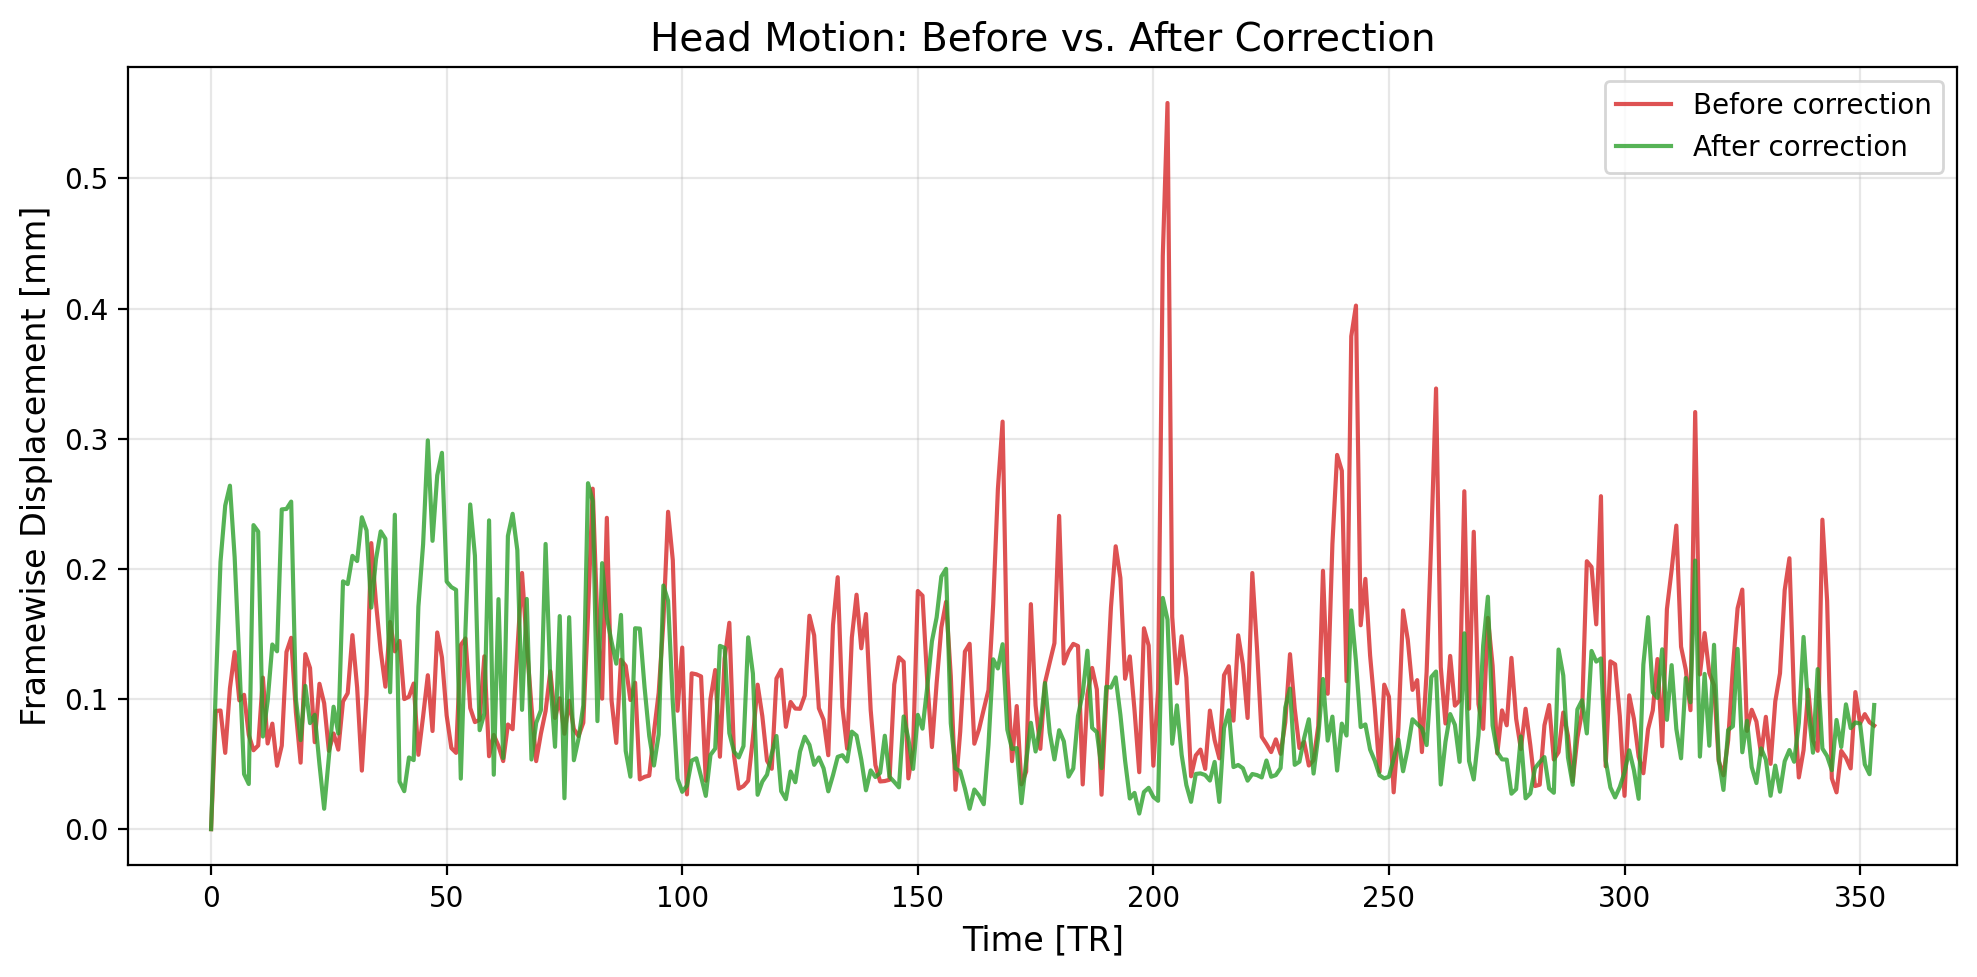

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Load framewise displacement (FD) values
fd_before = np.loadtxt(os.path.abspath('fd_before.txt'))
fd_after = np.loadtxt(os.path.abspath('fd_after.txt'))

# Plot
plt.figure(figsize=(10, 5))
plt.plot(fd_before, label='Before correction', color='tab:red', alpha=0.8)
plt.plot(fd_after, label='After correction', color='tab:green', alpha=0.8)

plt.xlabel('Time [TR]', fontsize=12)
plt.ylabel('Framewise Displacement [mm]', fontsize=12)
plt.title('Head Motion: Before vs. After Correction', fontsize=14)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<div class='alert alert-info'>
    <b>ToThink (0 points):</b>  
    As you can see above, the major spike is gone after motion correction.  
    However, it looks like there is more movement at the beginning *after* motion correction.  
    Why do you think that is?
</div>

<details>
<summary><b>💡Solution</b> (click to expand)</summary>

Motion correction aligns all volumes to a chosen **reference volume** (often the first or the middle one).  
If the participant’s head was in a different position at the end of the scan, the correction will introduce apparent “extra” movement in those early frames.  
This doesn’t necessarily reflect more motion by the participant, but simply the adjustment needed to bring early volumes into alignment with the reference.

</details>

The illustration above shows that motion correction can be very effective at reducing movement artefacts.  
However, it is **not perfect**:  

- If a participant moves excessively, the algorithm may fail to fully correct the data, and those scans may need to be excluded from analysis.  
- Even after correction, some **residual motion effects** remain.  

For this reason, motion parameters are often included as **confound regressors** in later analyses.  
You will see how this works in the upcoming notebooks on **GLM fitting** and **functional connectivity**.  

fMRIPrep produces a detailed **motion report** for each dataset.  
Below you can see a key excerpt from that report.  

![fMRIPrep Movement Report](figure_fMRIPrep_movement.png)



The figure provides several useful diagnostics:  

- **Top traces**: show the average time series for  
  - **global signal (GS)**,  
  - **cerebrospinal fluid (CSF)**, and  
  - **white matter (WM)**.  
  Since we do not expect meaningful BOLD-related activity in these regions, these signals can serve as **noise estimates**.  

- **Bottom traces**: show  
  - **framewise displacement (FD)** — already discussed above, and  
  - **DVARS** (the root mean square of temporal derivatives).  
    DVARS captures the change in signal intensity between consecutive volumes and is another indicator of noise.  
    Spikes in these traces often reflect sudden participant motion.  

---

At the very bottom is a **carpet plot**.  
This is created by stacking voxel time series from different structures and displaying them across the full scan:  

- left and right cerebral cortex (**CtxL, CtxR**)  
- left and right cerebellum (**CbL, CbR**)  
- white matter and CSF (**WM+CSF**)  
- other brain regions (**Other**)  
- voxels at the brain boundary (**Edge**)  

Notice the vertical stripes running through all structures: these are most likely caused by motion artefacts.  

For more details on interpreting carpet plots, see: [Power, 2022](https://doi.org/10.3389/fnimg.2022.1073734).  

<div class='alert alert-warning'>
<b>ToDo</b> (1 point): 

The image below shows the fMRIPrep data quality report for two participants. 

**Participant A**:
![fMRIPrep Movement A](figure_fMRIPrep_movement_a.png)

**Participant B**:
![fMRIPrep Movement B](figure_fMRIPrep_movement_b.png)

</div>



👉 Which participant above shows better data quality?

* Participant A
* Participant B
* Roughly the same

In [17]:
answer_7 = "Roughly the same"   # enter your answer inside the string quotes

<div class='alert alert-warning'>
<b>📝 ToDo (1 point):</b>  

In many analyses, we want to **exclude time points with excessive motion** — a process called *censoring*.  

Your task:  
1. Identify all TRs where **FD > 0.2 mm**.  
2. Also mark the **preceding and following TR** of each flagged time point.  
3. Create a binary vector `censor_vector` of the same length as the dataset:  
   - `1` = TR should be excluded (high motion)  
   - `0` = TR can be included  

👉 Store the result in a variable called `censor_vector`.  
</div>

In [18]:
import numpy as np

# Load FD (framewise displacement) time series
FD = np.loadtxt('fd_after.txt')  # fixed extra parenthesis

# --- Implement your solution here ---
# YOUR CODE HERE
censor_vector = np.zeros(shape = len(FD))

for i in range(0,len(FD)-1):
    if FD[i,] > 0.2 or FD[i-1,] > 0.2 or FD[i+1,] > 0.2:
        censor_vector[i] = 1

print(censor_vector, FD) 
# raise NotImplementedError()

[0. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1.
 1. 0. 0. 0. 0. 0. 0. 1. 1. 1. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 1. 1. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.

In [19]:
# Feedback cell
if "censor_vector" not in locals():
    print('The variable "censor_vector" is not defined. Check that you created and named the variable correctly.')
elif not censor_vector.shape == (354,):
    print('"censor_vector" should be a vector with shape (354,).')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


### 3. Susceptibility Distortion Correction  

The BOLD signal is influenced by the magnetic field of the scanner.  
Since this field is never perfectly uniform, it produces **geometric distortions** in the images.  
These artefacts are especially pronounced in regions such as the **frontal lobes** and **temporal lobes**.  

---

### How do we correct them?  

Several approaches exist, but all require **additional images** beyond the main functional run:  

- **Field map method** → acquires a separate “map” of the magnetic field inhomogeneities.  
- **Topup method** → acquires a short set of images with **opposite phase-encoding directions**.  

At the **UvA Imaging Centre**, the *topup* approach is commonly used. For example:  

- If the main fMRI run is acquired **anterior → posterior**,  
- we also acquire a few volumes **posterior → anterior** just before the run.  

By combining the information from these two directions, we can estimate the distortions and correct them.  

---

### What does this look like?  

Conceptually, images acquired with different phase-encoding directions look like this:  

![encoding_directions](figure_susceptibility_illustration.png)  

These opposite distortions can then be used to compute a **fieldmap**.  
The example below shows where the image needs to be shifted in the phase-encoding direction (**red**) or in the opposite direction (**blue**) in order to correct the distortion.  

This is how we go from *“squishy”* and *“stretchy”* … to *“just right”*.  

---

We won’t cover the physics or algorithms in detail (this isn’t an MRI physics course), but it’s important for you to be able to **recognise susceptibility distortions** and understand what the correction achieves.  



![fieldmap](figure_fMRIPrep_fieldmap.png)

![fieldmap](figure_fMRIPrep_fieldmap.png)

The displacements estimated in the fieldmap above are applied to correct image distortions.  
After correction, the functional images should more closely resemble the anatomical images.  

---

### What should you check?  

When assessing data quality, always compare the images **before and after susceptibility distortion correction**:  

- **If correction worked well**: functional images should align better with the anatomy, with reduced “squishing” or “stretching.”  
- **If correction failed**: residual distortions may remain.  
  - This can happen if the participant moved too much,  
  - or if there is an error in the metadata (e.g. wrong phase-encoding direction specified).  
  - In severe cases, the dataset may need to be excluded from further analysis.  



<div class='alert alert-info'>
    <b>ToThink (0 points):</b> 
    <p>
     You have now seen the importance of susceptibility artefacts in fMRI data
    </p>
    <p>
      Imagine you are planning a new fMRI study:  <br>
    </p>
    <p>
 👉 Should you acquire an image with the <b>opposite phase-encoding direction</b> before <b>each fMRI run</b>,  
        or just <b>one for the whole session</b>?  
    </p>
    <p>
    What might be the advantages and disadvantages of each approach?        
    </p>

</div>

<details>
<summary><b>💡Solution</b> (click to expand)</summary>

- **Opposite phase-encoding image before each run**  
  - More accurate correction, since distortions are estimated from images acquired immediately before the run.  
  - Reduces risk of participant movement or scanner drift changing the distortion field between runs.  
  - Increases scan time (overhead for each run).  

- **One opposite phase-encoding image per session**  
  - Faster (saves time, especially in long protocols).  
  - Reduces participant burden.  
  - Assumes distortions remain stable across the entire session.  
  - Less robust if the participant moves significantly or if field inhomogeneities change over time.  

In practice, many labs choose a **compromise**: acquire a short set of opposite-encoding images once at the start (or end) of the session, unless extreme accuracy is required.
</details>

### 4. Slice Timing Correction  

In fMRI, the brain is scanned one **slice** at a time.  
Because the slices are acquired sequentially, each one is captured at a **slightly different time point** within the same TR (repetition time).  

This creates a small **temporal misalignment** between slices:  
- some are recorded earlier,  
- others later.  

**Slice timing correction** adjusts the data so that all slices are aligned in time, as if they had been acquired simultaneously.  

Let's look at the time course of two voxels. The voxel marked in red in the image below was acquired before the voxel marked in blue. 

top voxel time course (first 10 points): [0.05374851 0.29926766 0.6566312  0.96539708 0.93171828 0.9806634
 1.11305489 0.88983756 0.54491491 0.3673501 ]
bottom voxel time course (first 10 points): [0.02719192 0.35650863 0.68750356 0.90581038 0.80470276 0.89763068
 0.99397322 0.85180877 0.6307032  0.68570332]


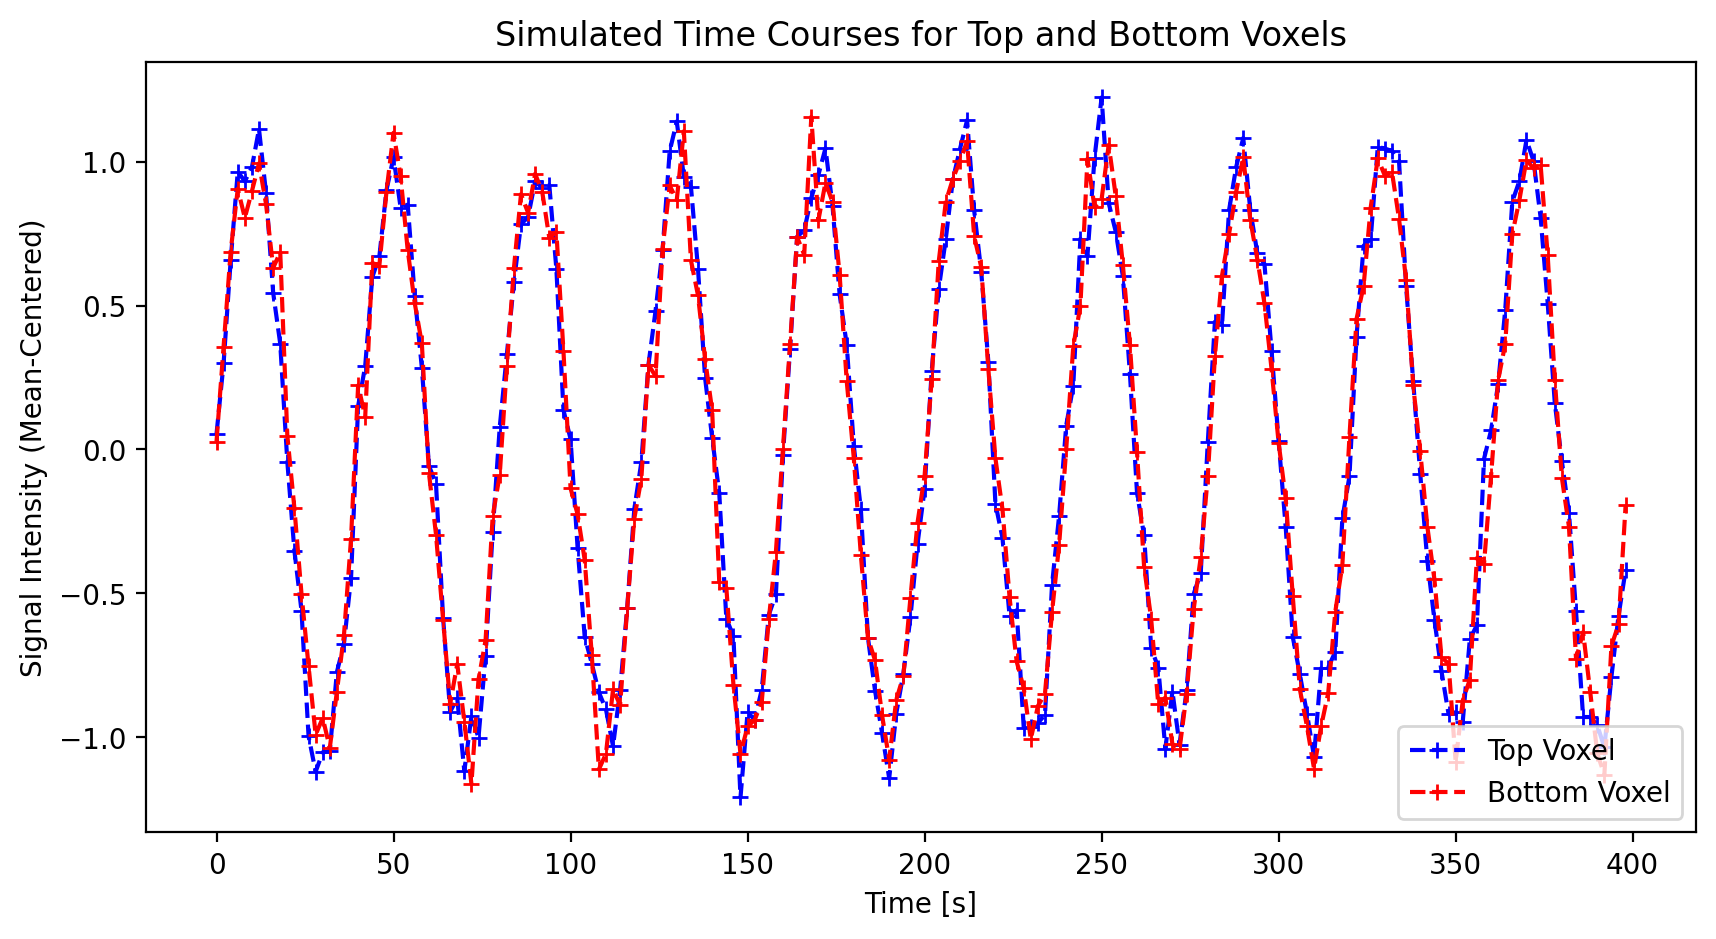

In [20]:
# Simulation parameters
n_timepoints = 200  # Number of time points
TR = 2.0            # Repetition time in seconds
np.random.seed(42)  # For reproducible results
slice_times = np.arange(0, n_timepoints * TR, TR)


# Define simulated voxel time courses with low-frequency components and noise
def simulate_time_course(n_timepoints, frequency=0.05, noise_level=0.1):
    time = np.arange(n_timepoints)
    # Simulate a low-frequency oscillation and add random noise
    time_course = np.sin(2 * np.pi * frequency * time) + noise_level * np.random.randn(n_timepoints)
    # Mean center the time course
    time_course = time_course - np.mean(time_course)
    return time_course

# Generate simulated time courses for 'top' and 'bottom' voxels
time_courses = []
for name in ['top', 'bottom']:
    time_course = simulate_time_course(n_timepoints)
    time_courses.append({
        'name': name,
        'time_course': time_course
    })

# Print out the simulated time courses
for tc in time_courses:
    print(f"{tc['name']} voxel time course (first 10 points):", tc['time_course'][:10])
    
    
# Plotting the simulated time courses
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

# Plot the time courses for 'top' and 'bottom' voxels
ax.plot(slice_times, time_courses[0]['time_course'], label='Top Voxel', color='blue', linestyle='--', marker='+')
ax.plot(slice_times, time_courses[1]['time_course'], label='Bottom Voxel', color='red', linestyle='--', marker='+')

# Set titles and labels
ax.set_title('Simulated Time Courses for Top and Bottom Voxels')
ax.set_xlabel('Time [s]')
ax.set_ylabel('Signal Intensity (Mean-Centered)')
ax.legend()

# Display the plot
plt.show()

When plotting the time courses, we should take into account that the slices were acquired at different times. I added grey lines that indicate the times at which the bottom voxel was acquired.

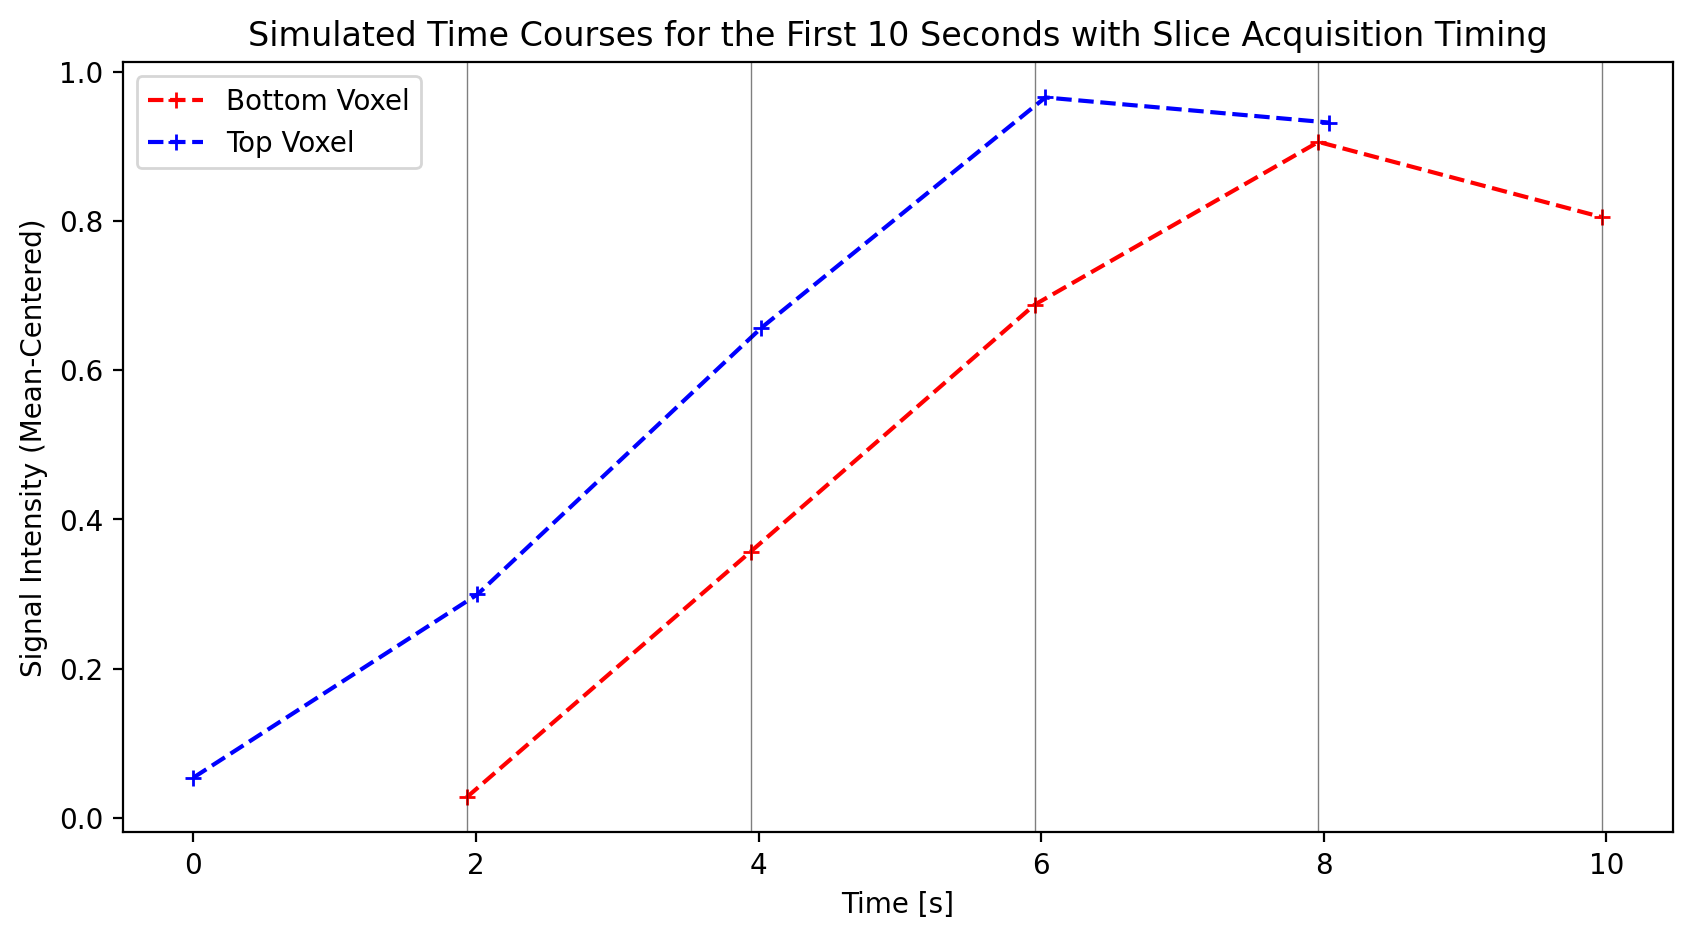

In [21]:
# Simulation parameters
n_timepoints = 200
TR = 2.0  # seconds
n_z_slices = 30  # Hypothetical number of slices for simulation
time_for_single_slice = TR / n_z_slices

# Simulated slice times across all time points
slice_times = np.linspace(0, n_timepoints * TR, n_timepoints)
slice_times_bottom = slice_times[:5] + (n_z_slices - 1) * time_for_single_slice  # First 5 points for bottom
slice_times_top = slice_times[:5] + 0 * time_for_single_slice                    # First 5 points for top

# Plotting the time courses for the first 10 seconds
plt.figure(figsize=(10, 5))
plt.plot(slice_times_bottom, time_courses[1]['time_course'][:5], label='Bottom Voxel', color='red', linestyle='--', marker='+')
plt.plot(slice_times_top, time_courses[0]['time_course'][:5], label='Top Voxel', color='blue', linestyle='--', marker='+')

# Add labels and legend
plt.xlabel('Time [s]')
plt.ylabel('Signal Intensity (Mean-Centered)')
plt.legend()

# Add vertical lines for each slice acquisition time within the first 10 seconds
for slice_time in slice_times_bottom:
    plt.axvline(slice_time, color='black', linestyle='-', linewidth=0.5, alpha=0.5)

plt.title("Simulated Time Courses for the First 10 Seconds with Slice Acquisition Timing")
plt.show()

As you can see, the signal from the **top voxel** was acquired slightly later than the signal from the **bottom voxel**.  
How can we deal with this?  

One solution is to estimate what the voxel values would have been **if they had been acquired at the same time point**.  
The dotted lines in the plot show this idea: they represent the **interpolated values** that we expect the signal to have at the reference time.  

This interpolation gives us the *best possible estimate* of what we would have measured if all slices were acquired simultaneously.  
In the code below, we implement this by fitting a **linear function** to the time series points and then calculating the expected value of that function at the acquisition time of the bottom voxel.  

Text(0, 0.5, 'Signal Intensity')

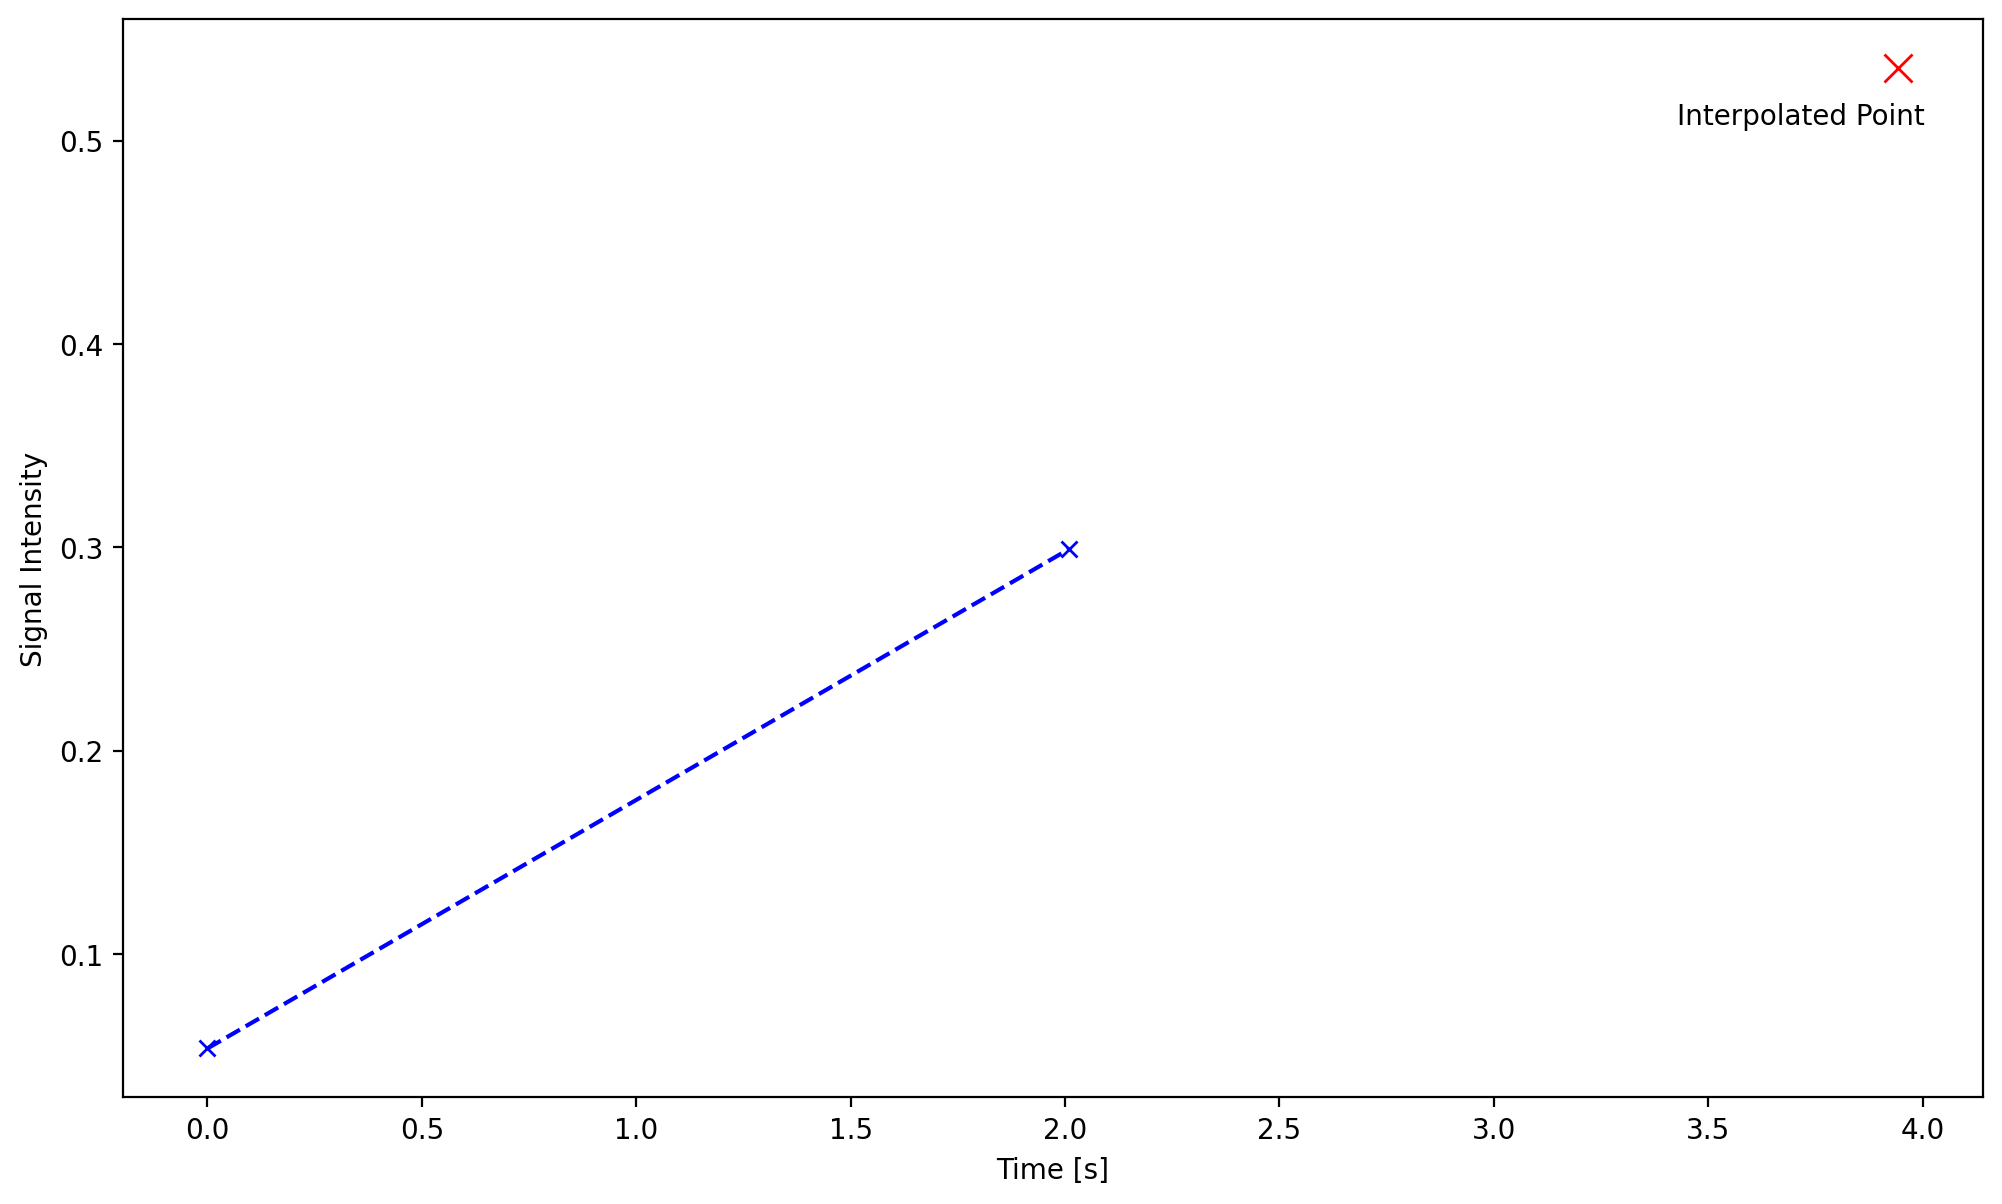

In [22]:
top_x1, top_y1 = slice_times_top[0], time_courses[0]['time_course'][0]
top_x2, top_y2 = slice_times_top[1], time_courses[0]['time_course'][1]

bottom_x1, bottom_y1 = slice_times_bottom[0], time_courses[1]['time_course'][0]
bottom_x2, bottom_y2 = slice_times_bottom[1], time_courses[1]['time_course'][1]

plt.plot([top_x1, top_x2], [top_y1, top_y2], color='blue', marker='x', linestyle='--')

def calculate_new_y(x, top_x1, top_y1, top_x2, top_y2):
    slope = (top_y2 - top_y1) / (top_x2 - top_x1)
    intercept = top_y1 - slope*top_x1
    y = slope*x + intercept
    return slope, y

slope, new_y = calculate_new_y(bottom_x2, top_x1, top_y1, top_x2, top_y2)
plt.plot(bottom_x2, new_y, color='red', marker='x', markersize=10)
plt.annotate('Interpolated Point', (bottom_x2, new_y), textcoords="offset points", xytext=(-35,-20), ha='center')
plt.xlabel('Time [s]')
plt.ylabel('Signal Intensity')

We could, in principle, repeat this interpolation step manually for every time point.  
Fortunately, we don’t have to — libraries like **SciPy** provide built-in functions for this.  

In the code below, we use **linear spline interpolation** from SciPy.  
This method fits straight-line segments between the observed time points and then evaluates the function at the desired time (e.g., the acquisition time of the bottom voxel).  

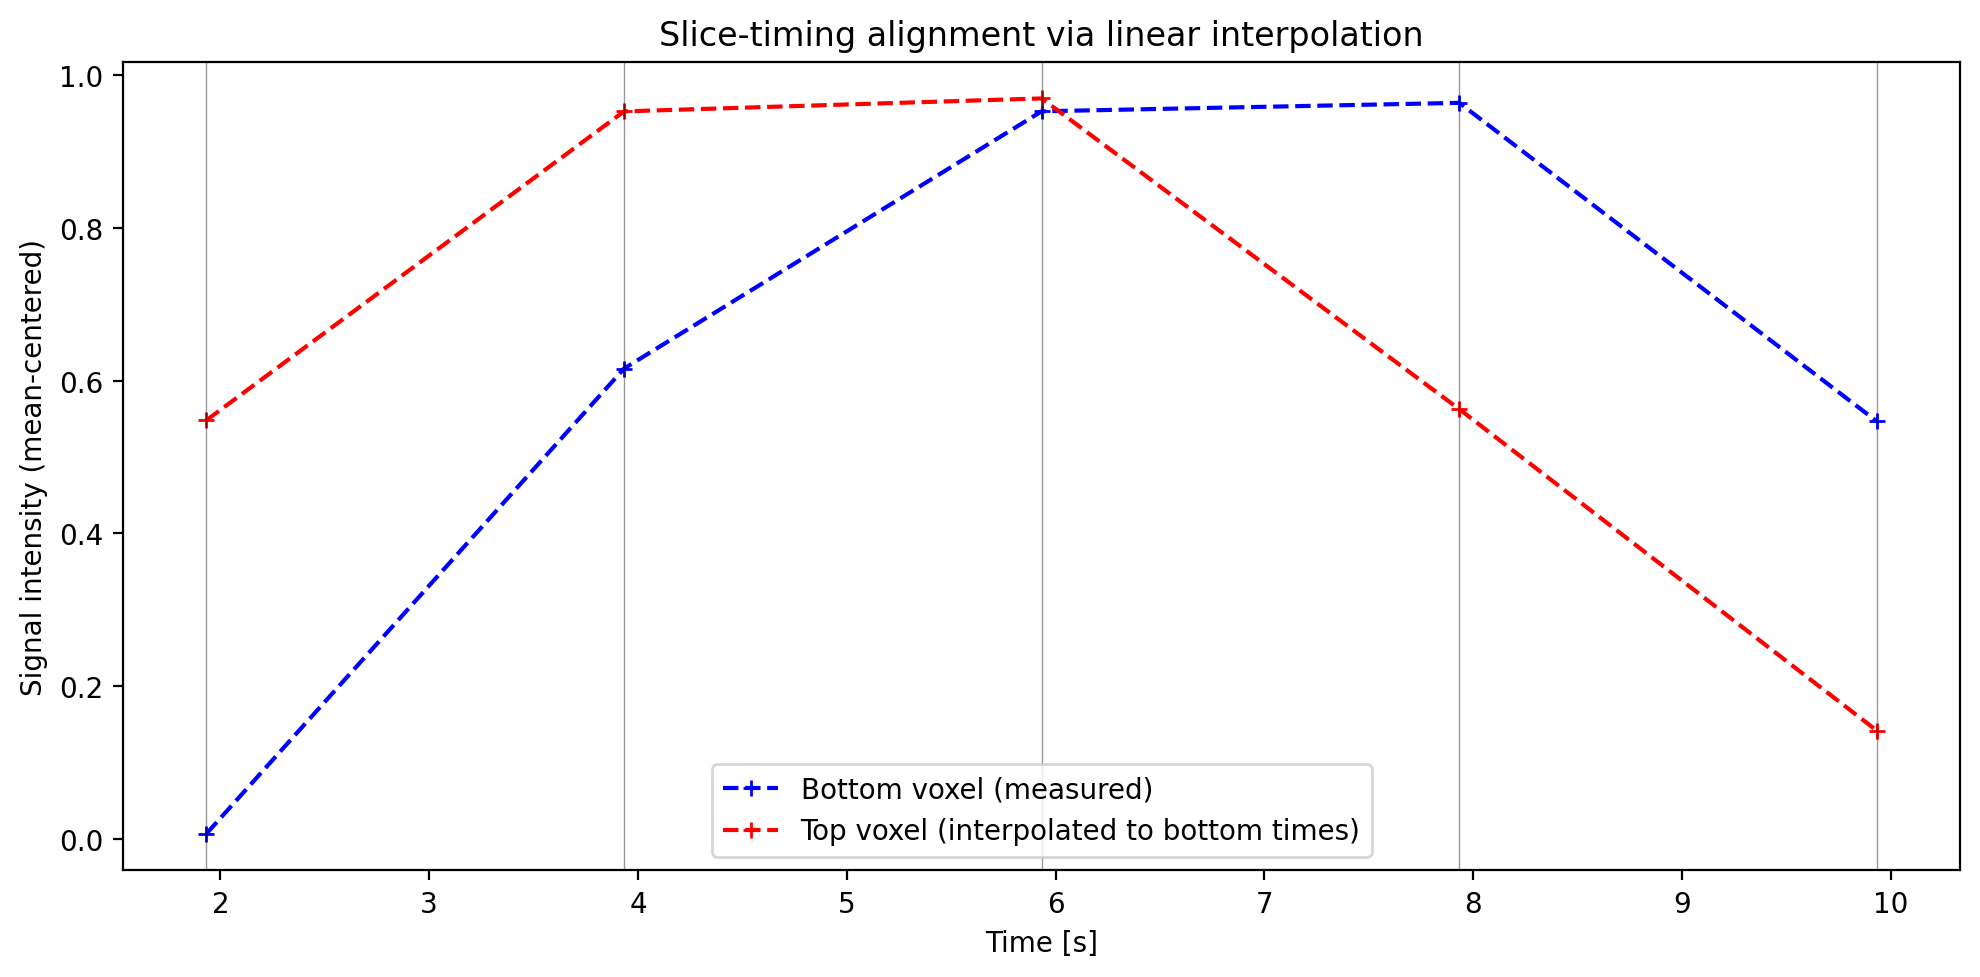

In [23]:
# --- Slice-timing demo: align "top" voxel to "bottom" voxel times via linear interpolation ---

import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# Simulation parameters
n_timepoints   = 200
TR             = 2.0         # seconds
n_z_slices     = 30          # number of slices
dt_slice       = TR / n_z_slices  # time between successive slice acquisitions within a TR

# We'll visualise only the first 10 s to keep the plot readable
t_window       = 10.0
n_pts_window   = int(t_window / TR)  # number of whole TRs in the window (here: 5)

# Acquisition times (start of each TR)
t_tr           = np.arange(n_timepoints) * TR

# Slice acquisition times for two example voxels:
# - "top" voxel acquired at the start of each TR
# - "bottom" voxel acquired near the end of each TR
t_top          = t_tr[:n_pts_window] + 0 * dt_slice
t_bottom       = t_tr[:n_pts_window] + (n_z_slices - 1) * dt_slice

# --- Example time courses ---
rng = np.random.default_rng(42)
true_signal    = np.sin(2 * np.pi * (t_tr / 20.0))                 # slow sinusoid
top_signal     = true_signal + 0.02 * rng.standard_normal(t_tr.shape)
bottom_signal  = true_signal + 0.02 * rng.standard_normal(t_tr.shape)

# Take the first few samples corresponding to our 10 s window
y_top_window     = top_signal[:n_pts_window]
y_bottom_window  = bottom_signal[:n_pts_window]

# --- Interpolate "top" to the acquisition times of "bottom" ---
# Linear (piecewise) interpolation; extrapolate if needed
top_to_bottom = interp1d(t_top, y_top_window, kind="linear",
                         bounds_error=False, fill_value="extrapolate")

y_top_interp_at_bottom = top_to_bottom(t_bottom)

# --- Plot ---
plt.figure(figsize=(10, 5))
plt.plot(t_bottom, y_bottom_window, label='Bottom voxel (measured)', linestyle='--', marker='+', color='blue')
plt.plot(t_bottom, y_top_interp_at_bottom, label='Top voxel (interpolated to bottom times)', linestyle='--', marker='+', color='red')

# Vertical lines to show each (bottom) slice time within the window
for tb in t_bottom:
    plt.axvline(tb, color='k', linestyle='-', linewidth=0.5, alpha=0.4)

plt.xlabel('Time [s]')
plt.ylabel('Signal intensity (mean-centered)')
plt.title('Slice-timing alignment via linear interpolation')
plt.legend()
plt.tight_layout()
plt.show()

In practice, you will almost never need to perform slice-timing correction manually.  
Most neuroimaging software packages include dedicated functions for this step, and **fMRIPrep** will apply it automatically if slice-timing information is available in the metadata.  

However, slice-timing correction is **more error-prone than many other preprocessing steps**.  
Mistakes are difficult to detect just by looking at the data, but they can seriously affect your results.  

❗Always verify that the slice-timing information in your BIDS metadata matches the **protocol file** from the scanner.  

<div class='alert alert-warning'>
<b>ToDo (1 point):</b>  

A colleague has shared some fMRI data with you — but unfortunately, it’s not organised according to modern standards (i.e. not BIDS).  
You’d like to run slice-timing correction with **fMRIPrep**, and you know the following about the acquisition:  

- TR = <code>2.0</code> seconds  
- Number of slices along z = <code>60</code>  
- Acquisition is <b>ascending interleaved</b>  
- <b>Indexing convention</b>: slice indices run from <code>0</code> (bottom/inferior) to <code>59</code> (top/superior)

<b>Definitions</b>  
- <i>Ascending interleaved</i> means slices are acquired in two passes:  
  1) all even-indexed slices in ascending order: <code>0, 2, 4, …, 58</code>  
  2) then all odd-indexed slices in ascending order: <code>1, 3, 5, …, 59</code>  
- Let <code>dt = TR / n_slices</code> be the time between successive slice acquisitions within a volume.  
- The array <code>slicetimes</code> must be length 60 where <code>slicetimes[i]</code> is the <b>acquisition time (in seconds)</b> of slice <code>i</code> within the TR.

<b>Your task</b>  
Create <code>slicetimes</code> using vectorised NumPy operations (no Python for-loops).

<i>Hints</i>  
- Build the acquisition order array <code>order</code> as above.  
- If slice <code>order[k]</code> was acquired k-th (starting at 0), then its time is <code>k * dt</code>.  
- You can fill <code>slicetimes</code> with indexing.

![Slice Order](https://www.fil.ion.ucl.ac.uk/spm/docs/assets/figures/slice_timing_figure.png)
    
 </div>

In [24]:
# --- Implement your solution here ---
# YOUR CODE HERE

TR = 2.0
n_slices = 60
dt = TR / n_slices

# acquisition order: evens then odds (ascending interleaved starting at 0)
order = np.concatenate([np.arange(0, n_slices, 2),
                        np.arange(1, n_slices, 2)])

# times for the k-th acquired slice (this is acquisition-order times)
times_acqorder = np.arange(n_slices) * dt   # shape (60,)

# slicetimes[i] = acquisition time (in seconds) of slice i (index order 0..59)
slicetimes = np.empty(n_slices, dtype=float)
slicetimes[order] = times_acqorder

# checks 
autograder_check = np.all(np.diff(slicetimes) >= 0)

per_pass_check = (np.all(np.diff(slicetimes[0::2]) >= 0) and
                  np.all(np.diff(slicetimes[1::2]) >= 0))

# acquisition-order times (should be increasing)
acqorder_times = slicetimes[order]
acqorder_check = np.all(np.diff(acqorder_times) >= 0)

# raise NotImplementedError()

print(f"Number of slices: {len(slicetimes)}")
print(f"First 10 slice times: {slicetimes[:10]}")
print(f"Last 10 slice times: {slicetimes[-10:]}")

Number of slices: 60
First 10 slice times: [0.         1.         0.03333333 1.03333333 0.06666667 1.06666667
 0.1        1.1        0.13333333 1.13333333]
Last 10 slice times: [0.83333333 1.83333333 0.86666667 1.86666667 0.9        1.9
 0.93333333 1.93333333 0.96666667 1.96666667]


In [25]:
# Feedback cell
if "slicetimes" not in locals():
    print('The variable "slicetimes" is not defined. Check that you created and named the variable correctly.')
elif not isinstance(slicetimes, np.ndarray):
    print('"slicetimes" should be a NumPy array.')
elif slicetimes.shape != (60,):
    print('"slicetimes" should be a one-dimensional array with 60 elements.')
elif not np.all(np.diff(slicetimes) >= 0):
    print('Slice times should increase monotonically with acquisition order.')
elif not np.isclose(np.max(slicetimes) - np.min(slicetimes), 2.0, rtol=0.05):
    print('The slice times should span approximately one TR (2 seconds). Check your calculation of time spacing.')
else:
    print('Your answer passed the automated checks.')

Slice times should increase monotonically with acquisition order.


<div class='alert alert-info'>
    <b>ToThink (0 points):</b>  
    What do you think might be the <b>advantages</b> and <b>disadvantages</b> of using an interleaved slice acquisition strategy?
</div>

<details>
<summary><b>💬 Suggested Answer</b> (click to expand)</summary>

**Advantages**  
- Reduces *slice-to-slice cross-talk*: adjacent slices are not excited one after the other, which improves signal quality.  
- Provides more uniform signal across the brain compared to purely sequential acquisition.  

**Disadvantages**  
- More complex slice-timing pattern, which requires careful slice-timing correction.  
- If slice-timing metadata is missing or mis-specified, it is harder to detect and can introduce subtle errors into analyses.  
- Slightly more difficult for students/researchers to intuitively interpret compared to simple ascending/descending order.  

</details>

### 5. Coregistration  

In most fMRI studies, we acquire one or more **high-resolution anatomical images** (T1-weighted and/or T2-weighted) during the same session as the functional scans.  
These anatomical images capture fine structural details and can be used, for example, to define specific brain regions of interest.  

To take advantage of this information, we need to **align the functional images with the anatomical images**.  
This alignment step is called **coregistration**.  

Here is an example from the same participant:  

!['T1w versus EPI'](figure_T1vsEPI.png)  

As you can see:  

- The **anatomical image** has much higher resolution and different contrast.  
- The **functional image (EPI)** is lower resolution and shows distortions, but contains the BOLD signal we want to analyse.  

To bring these images into alignment, we use the same principle as in motion correction:  
an **optimization algorithm** iteratively adjusts the parameters of an **affine transformation matrix** until the functional image best matches the anatomical image.  



<div class='alert alert-info'>  
<b>ToThink</b> (1 point):  

In the motion correction example above, we used **mean-squared error (MSE)** to find the optimal alignment between images.  

For **coregistration**, however, we usually rely on a different cost function — **mutual information (MI)**.  

👉 Why do you think MSE is not suitable for aligning a T1-weighted anatomical image with a BOLD fMRI image?  
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).

</div>

Since there are differences in the signal intensities of a certain tissue type \(e.g., white matter or grey matter\) between a T1 contrast and a T2\* contrast \(which is typically used for functional images\), comparing signal intensities acquired by different contrasts using a least squares function may not be appropriate. Instead, we need a cost function that can account for the differences produced by using pictures acquired with different contrasts.


### 6. Normalisation  

The final step in preprocessing is **normalisation** — transforming each participant’s brain images into a **common reference space**.  
This step is essential for group analyses: without it, voxel coordinates would refer to different brain locations across participants, making direct comparisons meaningless.  

---

### Why is normalisation needed?  
The figure below shows the same voxel coordinates in the native anatomical space of several participants:  

!['Anatomy Comparison'](figure_anatomy_comparison.png)  

As you can see, the voxel is in different brain regions for each participant — in Participant 3, it’s not even inside the brain!  
If we compared activity in this voxel across participants, it would be like comparing *apples and oranges*.  
Normalisation ensures that the same voxel coordinates refer to the same anatomical location in everyone.  

---

### The MNI152 space  
The most widely used template is the **MNI152 space**, created by the Montreal Neurological Institute (MNI) and the International Consortium for Brain Mapping (ICBM).  

- It is based on the **average of 152 anatomical scans**.  
- Different “flavours” exist, such as **MNI152NLin2009cAsym**, which is the default in fMRIPrep.  
- This version (from 2009) uses non-linear registration and retains the natural **asymmetry between hemispheres**.  

For analysis, the exact variant often doesn’t matter — as long as all participants are transformed to the **same space**.  
But for reporting and comparing across studies, it’s important to **state explicitly** which template was used.  

---

### How do we normalise data?  
We use a **non-linear transformation**, which is more flexible than the affine transformations used for motion correction and coregistration.  

- Affine transforms can translate, rotate, scale, and shear.  
- But human brains vary in shape and size, so affine alone is not enough.  
- Non-linear transforms allow for local stretching and compression (“squishing”) to better align each participant’s anatomy with the template.  

In practice:  
1. The participant’s **anatomical image** is aligned to the MNI template.  
2. The resulting non-linear transformation is then applied to the **functional images**, bringing them all into the same space.  

<div class='alert alert-info'>
<b>ToThink (1 point):</b>  

Normalisation is usually performed on **skull-stripped images**, rather than raw anatomical scans.  
    
 👉 Why do you think removing the skull and other non-brain tissue makes normalisation more accurate?
    
💡 Keep your explanation concise — this will be graded manually (no feedback cell).
</div>

Stripping the skull and other non\-brain tissue would reduce the search space. If the input contains only brain voxels, the process would be optimised. Non\-brain tissue also varies between participants and may unnecessarily reduce the accuracy of the alignment. 


#### 6.1 Spatial Smoothing  

Even after careful preprocessing, small **misalignments** often remain between participants’ brain images.  
To reduce their impact, we usually apply **spatial smoothing**.  

Spatial smoothing works by averaging the signal across **neighbouring voxels**, which helps:  
- increase the signal-to-noise ratio, and  
- make data more comparable across subjects.  

In practice, smoothing is performed with a **Gaussian kernel**:  
- The kernel’s size is described by its **full width at half maximum (FWHM)** —  
  the width of the Gaussian curve at half of its peak value.  
- FWHM is specified in **millimetres**, determining how much neighbouring signal is blended.  

---

👉 In the demo below, you’ll see how applying spatial smoothing changes the appearance of the data.  

In [26]:
# --- Interactive spatial smoothing ---

import os
import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image
import ipywidgets as widgets

# Load the functional image (BOLD reference)
func_filename = os.path.abspath('sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz')
func_img = image.load_img(func_filename)  # niimg

# Helper: extract a mid axial slice for display
def mid_axial_slice(np3d):
    x, y, z = np3d.shape
    sl = z // 2
    return np.flipud(np3d[:, :, sl].T)

# Update + plot based on FWHM (in mm)
def update_plot(fwhm):
    # Apply Gaussian smoothing with specified FWHM (mm).
    # If fwhm == 0, just show the original.
    func_smoothed = image.smooth_img(func_img, fwhm=fwhm) if fwhm > 0 else func_img

    # Fetch data for plotting
    orig_slice = mid_axial_slice(func_img.get_fdata())
    smooth_slice = mid_axial_slice(func_smoothed.get_fdata())

    # Plot
    plt.figure(figsize=(14, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(orig_slice, cmap='gray')
    plt.title('Functional Image (original)')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(smooth_slice, cmap='gray')
    plt.title(f'Functional Image (smoothed, FWHM = {fwhm:.1f} mm)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# Interactive slider for FWHM (mm)
sigma_slider = widgets.FloatSlider(
    value=2.0, min=0.0, max=10.0, step=0.1,
    description='FWHM (mm):', continuous_update=True
)

widgets.interactive(update_plot, fwhm=sigma_slider)

interactive(children=(FloatSlider(value=2.0, description='FWHM (mm):', max=10.0), Output()), _dom_classes=('wi…

<div class='alert alert-warning'>
<b>📝 ToDo (3 point):</b>  

**Goal:** find a **Gaussian smoothing FWHM (mm)** that achieves ~**5% noise reduction** while keeping spatial detail.

**Tasks**
1. Create a brain mask (e.g., with <code>nilearn.masking.compute_epi_mask</code>) and use it to compute statistics **only within brain**.
2. For a grid of candidate FWHM values (e.g., <code>[0, 1, 2, ..., 10]</code> mm), compute <code>NoiseReduction(FWHM)</code>.  
3. Choose the **smallest** FWHM for which <code>NoiseReduction ≥ 0.05</code> (i.e., ≥ 5%).  
4. Store your answer in a variable named <code>optimal_FWHM</code> (a float in millimetres).

> Hints:
> - Use <code>nilearn.image.smooth_img(func_img, fwhm=...)</code>.
> - Use the mask to index voxels when computing <code>np.std(...)</code>.
> - You may add a quick plot of NoiseReduction vs. FWHM to justify your choice (optional).

**Deliverable:**  
Set <code>optimal_FWHM</code> to your chosen kernel size (in mm).
</div>

In [27]:
# --- Noise reduction example ---
import numpy as np
from nilearn import image, masking
import nibabel as nib

def add_noise_img(niimg, noise_level=0.1, random_state=None):
    """
    Add Gaussian noise to a NIfTI image and return a new NIfTI (same affine/header).
    """
    rng = np.random.default_rng(random_state)
    data = niimg.get_fdata()
    noisy = data + rng.normal(loc=0.0, scale=noise_level, size=data.shape)
    return image.new_img_like(niimg, noisy)

def compute_noise_metrics(niimg, brain_mask_img=None):
    """
    Compute a simple noise metric: standard deviation of voxel values.
    If a brain mask is provided, compute within-mask std.
    """
    data = niimg.get_fdata()
    if brain_mask_img is not None:
        mask = brain_mask_img.get_fdata().astype(bool)
        vals = data[mask]
    else:
        vals = data.ravel()
    return float(np.std(vals))

def quantifying_noise_reduction(noisy_img, smoothed_img, brain_mask_img=None):
    """
    Print and return percent noise reduction between noisy and smoothed images.
    """
    noise_before = compute_noise_metrics(noisy_img, brain_mask_img)
    noise_after  = compute_noise_metrics(smoothed_img, brain_mask_img)
    percent_reduction = 100.0 * (noise_before - noise_after) / (noise_before + 1e-12)
    print(f'Noise before smoothing: {noise_before:.4f}')
    print(f'Noise after  smoothing: {noise_after:.4f}')
    print(f'Noise reduction: {percent_reduction:.2f}%')
    return percent_reduction

# ---------------------------
# Example usage

# (1) Optional: compute a brain mask so the metric focuses on brain voxels
brain_mask_img = masking.compute_epi_mask(func_img)

# (2) Create a noisy copy of the functional image
noisy_img = add_noise_img(func_img, noise_level=0.5, random_state=42)

# (3) Smooth the (noisy) image using a Gaussian kernel with FWHM in millimetres
func_smoothed = image.smooth_img(noisy_img, fwhm=2.0)

# (4) Quantify noise reduction (within brain mask)
_ = quantifying_noise_reduction(noisy_img, func_smoothed, brain_mask_img=brain_mask_img)

Noise before smoothing: 8852.1006
Noise after  smoothing: 8796.7669
Noise reduction: 0.63%


In [28]:
import numpy as np
from nilearn import image, masking

# --- Implement your solution here ---
# YOUR CODE HERE
brain_mask_img = masking.compute_epi_mask(func_img)

# Create noisy version of the functional image
noisy_img = add_noise_img(func_img, noise_level=0.5, random_state=42)

optimal_FWHM=[]

for i in range(10):
    smoothed = image.smooth_img(noisy_img, fwhm=i)
    reduction = quantifying_noise_reduction(noisy_img, smoothed, brain_mask_img)
    if reduction >= 5:
        optimal_FWHM = i
        break    
    
print(optimal_FWHM)
# raise NotImplementedError()

Noise before smoothing: 8852.1006
Noise after  smoothing: 8852.1006
Noise reduction: 0.00%
Noise before smoothing: 8852.1006
Noise after  smoothing: 8852.1006
Noise reduction: 0.00%
Noise before smoothing: 8852.1006
Noise after  smoothing: 8796.7669
Noise reduction: 0.63%
Noise before smoothing: 8852.1006
Noise after  smoothing: 8108.1027
Noise reduction: 8.40%
3


/usr/local/lib/python3.10/dist-packages/nilearn/image/image.py:207: UserWarning: The parameter 'fwhm' for smoothing is specified as 0. Setting it to None (no smoothing will be performed)
  warnings.warn("The parameter 'fwhm' for smoothing is specified "


In [29]:
# Feedback cell
if "optimal_FWHM" not in locals():
    print('The variable "optimal_FWHM" is not defined. Make sure you created it and used the correct name.')
elif not np.isscalar(optimal_FWHM):
    print('"optimal_FWHM" should be a single numeric value (float).')
elif optimal_FWHM < 0:
    print('"optimal_FWHM" cannot be negative. Check your calculation or selection step.')
elif optimal_FWHM > 20:
    print('"optimal_FWHM" seems unusually large — did you compute the noise reduction correctly?')
else:
    print('Your answer passed the automated checks.')

Your answer passed the automated checks.


## Back to Statistics: The Impact of Smoothing on Test Statistics

So far, we have seen that **spatial smoothing** reduces noise in the data by averaging neighbouring voxels.  
Conceptually, this has a direct impact on the **General Linear Model (GLM)** you learned about in earlier labs.

Recall the test statistic:

$$
t = \frac{\hat{\beta}}{\hat{\sigma}}
$$

- $\hat{\beta}$ = the estimated effect size (signal)  
- $\hat{\sigma}$ = the estimated standard error (noise)

---

### Simulation  

To make the link between preprocessing and statistics concrete, we will run a simulation.  

- We simulate a small **4D fMRI dataset**:  
  - 3D brain volume × 200 time points.  
  - Inside a small spherical region (ROI), the signal follows a simple **task design** (a block on/off regressor).  
  - Everywhere else, the signal is just random noise.  

- We then fit a simple **GLM** voxelwise:  
  $$
  Y = X\beta + \epsilon
  $$
  with one task regressor and an intercept.  
  We compute a **t-statistic** for the task contrast in every voxel.  

- Next, we repeat this analysis after applying different amounts of **spatial smoothing** (0, 2, 4, 6, 8 mm FWHM).  

---

### What to look for
1. **Inside the ROI**:  
   - Smoothing reduces noise, so the denominator $\hat{\sigma}$ in  
     $$
     t = \frac{\hat{\beta}}{\hat{\sigma}}
     $$  
     gets smaller.  
   - This means the **mean t-value inside the ROI increases**.  

2. **Outside the ROI**:  
   - Smoothing spreads the signal into neighbouring voxels.  
   - This increases apparent $|t|$-values just outside the true ROI.  
   - Result: higher sensitivity but lower spatial specificity.  

---

👉 This simulation illustrates the **trade-off** of smoothing:  
- **Pro:** boosts statistical sensitivity by reducing noise.  
- **Con:** blurs spatial detail, making it harder to localise small effects precisely.  

### Simulation  

To make the link between preprocessing and statistics concrete, we will run a simulation.  

- We simulate a small **4D fMRI dataset**:  
  - 3D brain volume × 200 time points.  
  - Inside a small spherical region (ROI), the signal follows a simple **task design** (a block on/off regressor).  
  - Everywhere else, the signal is just random noise.  

- We then fit a simple **GLM** voxelwise:  
  $$
  Y = X\beta + \epsilon
  $$
  with one task regressor and an intercept.  
  We compute a **t-statistic** for the task contrast in every voxel.  

- Next, we repeat this analysis after applying different amounts of **spatial smoothing** (0, 2, 4, 6, 8 mm FWHM).  

---

### What to look for
1. **Inside the ROI**:  
   - Smoothing reduces noise, so the denominator $\hat{\sigma}$ in  
     $$
     t = \frac{\hat{\beta}}{\hat{\sigma}}
     $$  
     gets smaller.  
   - This means the **mean t-value inside the ROI increases**.  

2. **Outside the ROI**:  
   - Smoothing spreads the signal into neighbouring voxels.  
   - This increases apparent $|t|$-values just outside the true ROI.  
   - Result: higher sensitivity but lower spatial specificity.  

---

👉 This simulation illustrates the **trade-off** of smoothing:  
- **Pro:** boosts statistical sensitivity by reducing noise.  
- **Con:** blurs spatial detail, making it harder to localise small effects precisely.  

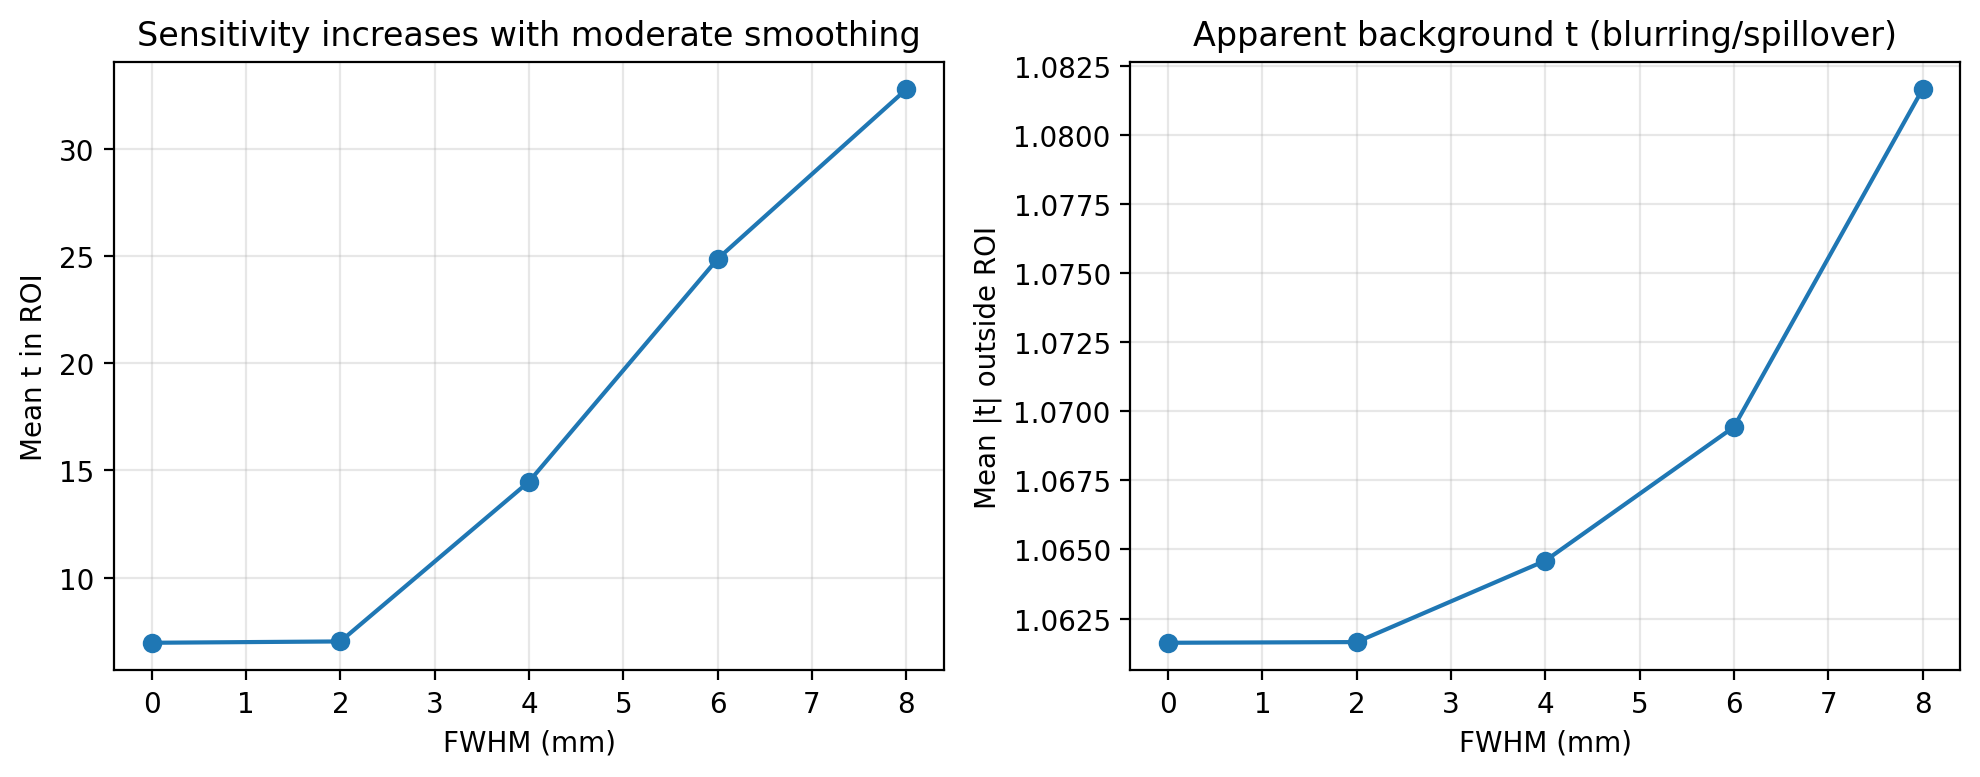

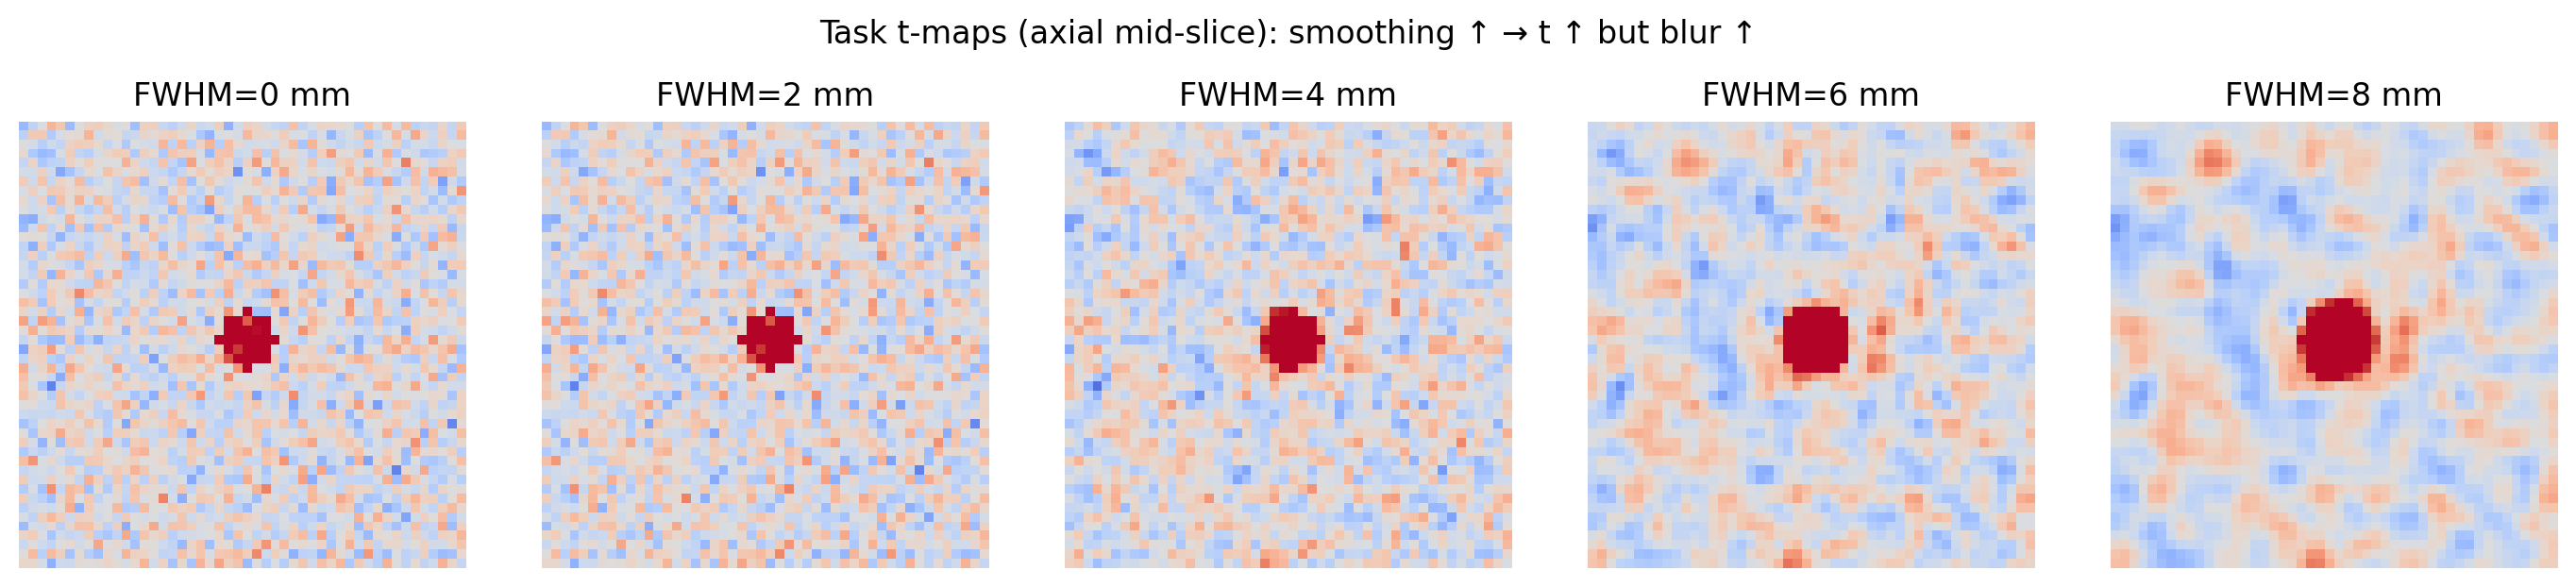

Mean t in ROI by FWHM: {0: '6.96', 2: '7.02', 4: '14.47', 6: '24.86', 8: '32.76'}
Mean |t| outside ROI by FWHM: {0: '1.06', 2: '1.06', 4: '1.06', 6: '1.07', 8: '1.08'}


In [30]:
# Simulation: How spatial smoothing affects GLM t-statistics

import numpy as np
import matplotlib.pyplot as plt
import nibabel as nib
from nilearn import image

# -----------------------------
# 1) Build synthetic 4D dataset
# -----------------------------
rng = np.random.default_rng(42)

# Spatial grid (in mm): 3 mm isotropic voxels
vx = 3.0
nx, ny, nz = 48, 48, 32
affine = np.diag([vx, vx, vx, 1.0])

# Time dimension
T = 200
TR = 2.0  # seconds

# Design: simple boxcar (on/off blocks) + intercept
block_len = 20
on = np.tile(np.r_[np.ones(block_len), np.zeros(block_len)], T // (2 * block_len))
X = np.c_[np.ones(T), on]  # [intercept, task]
# Normalise task regressor for clarity (optional but common)
X[:, 1] = (X[:, 1] - X[:, 1].mean()) / X[:, 1].std()

# True effect β inside a spherical ROI, zero elsewhere
beta_task = 1.0  # amplitude of task effect (arbitrary units)
beta_intercept = 100.0  # baseline signal level (arbitrary units)

# Make a spherical ROI (radius ~ 3 voxels)
cx, cy, cz = nx // 2, ny // 2, nz // 2
xg, yg, zg = np.meshgrid(np.arange(nx), np.arange(ny), np.arange(nz), indexing="ij")
roi = ( (xg - cx)**2 + (yg - cy)**2 + (zg - cz)**2 ) <= (3.0**2)

# Noise parameters
sigma_noise = 2.0  # Gaussian noise SD
# Optional: add a tiny AR(1)-like temporal autocorrelation by filtering
def ar1_like(ts, rho=0.3):
    y = np.zeros_like(ts)
    for t in range(len(ts)):
        y[t] = (rho * y[t-1] if t > 0 else 0.0) + ts[t]
    return y

# Generate 4D data: Y(x,y,z,t) = β0 + β1*task(t) (inside ROI) + noise
Y = np.empty((nx, ny, nz, T), dtype=np.float32)
task_ts = X[:, 1]

for ix in range(nx):
    for iy in range(ny):
        # vectorised over z for some speed
        mask_line = roi[ix, iy, :]
        # baseline
        baseline_line = np.full((nz, T), beta_intercept, dtype=np.float32)
        # task effect only in ROI voxels
        effect_line = np.zeros((nz, T), dtype=np.float32)
        effect_line[mask_line, :] = beta_task * task_ts  # same effect for all ROI voxels
        # noise
        noise_line = rng.normal(0.0, sigma_noise, size=(nz, T))
        # add light AR(1) temporal structure
        for k in range(nz):
            noise_line[k, :] = ar1_like(noise_line[k, :], rho=0.3)
        Y[ix, iy, :, :] = baseline_line + effect_line + noise_line

# Wrap as 4D NIfTI
img = nib.Nifti1Image(Y, affine)

# -----------------------------
# 2) GLM fit (OLS) voxelwise
# -----------------------------
# Precompute OLS helper matrices
X_ = X  # (T x 2)
XtX_inv = np.linalg.inv(X_.T @ X_)           # (2 x 2)
pinv_X = XtX_inv @ X_.T                      # (2 x T)
C = np.array([0, 1.0])                       # contrast for the task regressor

def fit_glm_and_t(nifti_img):
    """Return t-map for the task contrast."""
    data = nifti_img.get_fdata().astype(np.float32)  # (nx, ny, nz, T)
    # Reshape to 2D: V x T
    V = np.prod(data.shape[:3])
    Y2D = data.reshape(V, T)
    # β̂ (V x 2)
    beta_hat = Y2D @ pinv_X.T
    # Residuals
    Y_fit = beta_hat @ X_.T
    resid = Y2D - Y_fit
    dof = T - X_.shape[1]
    # σ̂^2 per voxel
    sigma2 = (resid**2).sum(axis=1) / max(dof, 1)
    # Var(β̂) = σ̂^2 * (X'X)^{-1}; for contrast c, Var(c'β̂) = σ̂^2 * c'(X'X)^{-1}c
    c_var = C @ XtX_inv @ C  # scalar
    # t = c'β̂ / sqrt(σ̂^2 * c'(X'X)^{-1}c)
    num = (beta_hat @ C)                    # (V,)
    den = np.sqrt(np.maximum(sigma2 * c_var, 1e-12))
    tvals = num / den
    return tvals.reshape(data.shape[:3])

# -----------------------------
# 3) Smooth at different FWHM
# -----------------------------
fwhm_list = [0, 2, 4, 6, 8]  # in mm
mean_t_in_roi = []
mean_abs_t_outside = []
maps = {}

for f in fwhm_list:
    # Smooth each volume (Nilearn handles 4D)
    smoothed = image.smooth_img(img, fwhm=f) if f > 0 else img
    tmap = fit_glm_and_t(smoothed)
    maps[f] = tmap
    # Metrics: signal vs. background
    roi_mask = roi
    bg_mask = ~roi_mask
    mean_t_in_roi.append(np.nanmean(tmap[roi_mask]))
    mean_abs_t_outside.append(np.nanmean(np.abs(tmap[bg_mask])))

# -----------------------------
# 4) Plots: t vs smoothing & slices
# -----------------------------
plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
plt.plot(fwhm_list, mean_t_in_roi, marker='o')
plt.xlabel('FWHM (mm)')
plt.ylabel('Mean t in ROI')
plt.title('Sensitivity increases with moderate smoothing')
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
plt.plot(fwhm_list, mean_abs_t_outside, marker='o')
plt.xlabel('FWHM (mm)')
plt.ylabel('Mean |t| outside ROI')
plt.title('Apparent background t (blurring/spillover)')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Show axial mid-slice t-maps for visual intuition
midz = nz // 2
ncols = len(fwhm_list)
plt.figure(figsize=(2.8*ncols, 3))
for i, f in enumerate(fwhm_list, 1):
    sl = maps[f][:,:,midz].T
    plt.subplot(1, ncols, i)
    plt.imshow(np.flipud(sl), cmap='coolwarm', vmin=-6, vmax=6)
    plt.title(f'FWHM={f} mm')
    plt.axis('off')
plt.suptitle('Task t-maps (axial mid-slice): smoothing ↑ → t ↑ but blur ↑', y=1.02)
plt.tight_layout()
plt.show()

# -----------------------------
# 5) Takeaways
# -----------------------------
print("Mean t in ROI by FWHM:", dict(zip(fwhm_list, [f"{v:.2f}" for v in mean_t_in_roi])))
print("Mean |t| outside ROI by FWHM:", dict(zip(fwhm_list, [f"{v:.2f}" for v in mean_abs_t_outside])))

<div class='alert alert-warning'>
<b>📝 ToDo (2 points):</b>  

Use the simulated <code>maps</code> (dictionary of FWHM → t-map) and <code>roi</code> (boolean ROI mask) from above.  

1. Compute the **mean t-value inside the ROI** for FWHM = 0 mm and FWHM = 6 mm.  
2. Compute the **mean |t|-value outside the ROI** for the same two smoothing levels.  
3. Based on your results, explain in **2–3 sentences** how smoothing affects:  
   - the test statistic inside the ROI, and  
   - apparent activations outside the ROI.  

👉 Store your results in variables called:  
- <code>mean_t_roi_0</code>  
- <code>mean_t_roi_6</code>  
- <code>mean_abs_t_out_0</code>  
- <code>mean_abs_t_out_6</code>  
</div>

In [31]:
# --- Q1: mean t inside ROI ---

# YOUR CODE HERE
# mean t in ROI
mean_t_roi_0 = np.nanmean(maps[0][roi])
mean_t_roi_6 = np.nanmean(maps[6][roi])
# raise NotImplementedError()

print("Mean t in ROI (0 mm):", mean_t_roi_0)
print("Mean t in ROI (6 mm):", mean_t_roi_6)

Mean t in ROI (0 mm): 6.958196650688828
Mean t in ROI (6 mm): 24.85675400449465


In [36]:
# Feedback cell
errors = 0

required_vars = ['mean_t_roi_0', 'mean_t_roi_6', 'mean_abs_t_out_0', 'mean_abs_t_out_6']

# 1. Check that all variables are defined
for var in required_vars:
    if var not in locals():
        print(f'The variable "{var}" is not defined. Make sure you created it and used the correct name.')
        errors += 1

# 2. Check variable types
for var in required_vars:
    if var in locals() and not np.isscalar(eval(var)):
        print(f'"{var}" should be a single numeric value (float).')
        errors += 1

# 3. Sanity checks (directional logic, not exact values)
if all(v in locals() for v in ['mean_t_roi_0', 'mean_t_roi_6']):
    if mean_t_roi_6 <= mean_t_roi_0:
        print('The mean t-value inside the ROI should increase with smoothing (check your computation).')
        errors += 1

if all(v in locals() for v in ['mean_abs_t_out_0', 'mean_abs_t_out_6']):
    if mean_abs_t_out_6 <= mean_abs_t_out_0:
        print('The mean |t|-value outside the ROI should increase with smoothing due to blurring.')
        errors += 1

if errors == 0:
    print('Your answer passed the automated checks.')
else:
    print(f'The automated checks found {errors} potential issue(s).')

Your answer passed the automated checks.


In [33]:
# --- Q2: mean |t| outside ROI ---

# YOUR CODE HERE
# Mean |t| outside ROI
bg_mask = ~roi
mean_abs_t_out_0 = np.nanmean(np.abs(maps[0][bg_mask]))
mean_abs_t_out_6 = np.nanmean(np.abs(maps[6][bg_mask]))

# raise NotImplementedError()

print("Mean |t| outside ROI (0 mm):", mean_abs_t_out_0)
print("Mean |t| outside ROI (6 mm):", mean_abs_t_out_6)

Mean |t| outside ROI (0 mm): 1.0616229070522551
Mean |t| outside ROI (6 mm): 1.0694347298124007


In [37]:
# YOUR CODE HERE
# raise NotImplementedError()

In this section, you saw how **spatial smoothing** directly connects preprocessing to the **statistics** of the GLM.  

- By averaging across neighbouring voxels, smoothing **reduces noise** and lowers the error term $\hat{\sigma}$, which increases $t$-values inside true activation regions.  
- At the same time, smoothing also **blurs the signal**, raising apparent activations outside the region and reducing spatial specificity.  

The key message is that **preprocessing choices shape the error term, and therefore the statistical conclusions we draw.** 

In [44]:
# Please run this cell to clear up space on the server. If you need the data again, just run the download cell at the beginning of the notebook.

for file in [
    "motion_effect.gif",
    "func_ref.nii.gz",
    "fd_before.txt",
    "fd_after.txt",
    "figure_fMRIPrep_movement.png",
    "figure_fMRIPrep_movement_a.png",
    "figure_fMRIPrep_movement_b.png",
    "figure_susceptibility_illustration.png",
    "figure_fMRIPrep_fieldmap.png",
    "figure_T1vsEPI.png",
    "figure_anatomy_comparison.png",
    "sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz",
    "sub-03_ses-1_acq-AxialNsig2Mm1_desc-preproc_T1w.nii.gz"
]:
    if os.path.isfile(file):
        os.remove(file)
        print(f'Removed file {file}')
    else:
        print(f'File {file} not found')

Removed file motion_effect.gif
Removed file func_ref.nii.gz
Removed file fd_before.txt
Removed file fd_after.txt
Removed file figure_fMRIPrep_movement.png
Removed file figure_fMRIPrep_movement_a.png
Removed file figure_fMRIPrep_movement_b.png
Removed file figure_susceptibility_illustration.png
Removed file figure_fMRIPrep_fieldmap.png
Removed file figure_T1vsEPI.png
Removed file figure_anatomy_comparison.png
Removed file sub-03_ses-1_task-face_run-1_space-T1w_boldref.nii.gz
Removed file sub-03_ses-1_acq-AxialNsig2Mm1_desc-preproc_T1w.nii.gz


### 🎉 Well done!  

In this section, we explored the key **preprocessing steps** that prepare fMRI data for statistical analysis.  
Each step reduces noise, aligns images, and ensures data from different participants can be meaningfully compared.  

- **Motion correction**: Aligns all functional volumes to a reference to reduce artefacts from head movement.  
- **Susceptibility distortion correction**: Uses additional scans (e.g. reversed phase-encoding) to correct distortions caused by magnetic field inhomogeneities.  
- **Slice timing correction**: Adjusts for the fact that slices are acquired at slightly different times within each TR.  
- **Coregistration**: Aligns the lower-resolution functional images with the high-resolution anatomical image.  
- **Normalisation**: Warps each participant’s brain into a **common space** (e.g. MNI152), making group comparisons possible.  
- **Spatial smoothing**: Increases signal-to-noise ratio by averaging neighbouring voxels, though at the cost of spatial specificity.  

Together, these steps ensure that the BOLD signal you model later is as clean, comparable, and interpretable as possible.  

---

### Up next: Implementing fMRI analyses in Nilearn  

In the next lab, you will put this knowledge into practice by learning how to **implement fMRI analyses in Python with Nilearn**.  
You’ll apply the **General Linear Model (GLM)** to real data, exploring how to set up a design matrix, fit the model, and interpret the results.  

<div class='alert alert-success'>
    <b>Tip</b>: When you are finished with your work, click "Validate" at the top of the notebook. This will run the entire notebook and tell you with there are any errors.
</div>